# **Airbnb Price Prediction in Cape Town: Advanced Machine Learning Analysis**
# **Executive Summary**
*This project develops a comprehensive machine learning solution to optimize Airbnb pricing in Cape Town's unique tourism market. By combining traditional machine learning with deep learning approaches, we deliver accurate price predictions and actionable insights for hosts, while contributing to the understanding of sharing economy dynamics in African markets. Our hybrid methodology ensures robust performance while exploring cutting-edge techniques.*

# 1. Business Understanding
## 1.1 Problem Statement
Airbnb hosts in Cape Town face significant challenges in setting optimal prices that balance occupancy rates with revenue maximization. The city's unique tourism patterns, diverse neighborhoods, and seasonal fluctuations create a complex pricing environment that traditional methods struggle to navigate. This project addresses the critical need for data-driven pricing strategies tailored to Cape Town's specific market conditions.

## 1.2 Project Objectives
**Main Objective:** Develop an accurate and interpretable machine learning system to predict optimal Airbnb listing prices in Cape Town, providing hosts with data-driven pricing recommendations and insights.

### Specific Objectives:

- Implement and compare multiple machine learning approaches including traditional algorithms and neural networks to identify the most effective pricing prediction methodology for this market
- Engineer advanced features that capture Cape Town's unique geographic, seasonal, and amenity-based pricing drivers
- Build model explainability capabilities that translate complex predictions into actionable business insights for hosts
- Develop a deployable pricing tool that demonstrates practical utility through an interactive web application
## 1.3 Success Metrics
- **Primary:** RMSE (Root Mean Squared Error) on log-transformed prices targeting <0.15
- **Secondary:** >70% of predictions within 15% of actual prices
- **Technical:** R² score >0.65 with comprehensive model explainability
- **Business:** Clear identification of top 5 pricing drivers in Cape Town market
## 1.4 Stakeholder Value
- **Airbnb Hosts:** Data-driven pricing decisions increasing revenue by 15-25%
- **Platform Efficiency:** Reduced price volatility and improved market transparency
- **Tourism Industry:** Better understanding of Cape Town's accommodation market dynamics
- **Research Community:** Insights into African sharing economy and emerging market applications
# 2. Data Understanding
**Purpose:** Gain comprehensive knowledge of the dataset, assess data quality, and identify patterns and relationships before modeling.

## 2.1 Data Sources
The data is from Inside Airbnb website.

## 2.2 Initial Data Exploration

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the dataset
listing = pd.read_csv('listings.csv')
listing.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,15007,https://www.airbnb.com/rooms/15007,20250928034929,2025-09-28,city scrape,Blaauwberg House on the beach in Bloubergstrand,Welcome to our self-catering beach-front famil...,"Bloubergstrand is a lovely, cosy suburb near C...",https://a0.muscache.com/pictures/3b654aa4-248e...,59072,...,4.94,4.94,4.85,NaN,f,1,1,0,0,0.33
1,15068,https://www.airbnb.com/rooms/15068,20250928034929,2025-09-28,city scrape,Grande Bay,Modern spacious apartment. Three bedrooms two...,Close to Eden on The Bay and lots of restauran...,https://a0.muscache.com/pictures/a09b3f0d-d43b...,59318,...,NaN,NaN,NaN,NaN,f,5,5,0,0,NaN
2,15077,https://www.airbnb.com/rooms/15077,20250928034929,2025-09-28,city scrape,Relaxed beach living in style,Our Superior Rooms (approx. 25 m²) are located...,It is probably the best hub in order to explor...,https://a0.muscache.com/pictures/4a8fceaa-655e...,59342,...,4.71,4.86,5.00,NaN,f,6,1,5,0,0.05
3,15199,https://www.airbnb.com/rooms/15199,20250928034929,2025-09-29,city scrape,Self catering apartment,NaN,NaN,https://a0.muscache.com/pictures/142776/5b6c9e...,59694,...,5.00,5.00,4.00,NaN,f,1,1,0,0,0.01
4,15354,https://www.airbnb.com/rooms/15354,20250928034929,2025-09-29,previous scrape,"Aurora Self Catering Units, Durbanville, Cape ...",Durbanville is centrally located for daytrips ...,Durbanville is a really lovely village half an...,https://a0.muscache.com/pictures/113126/f1bb90...,60196,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN


In [3]:
listing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26877 entries, 0 to 26876
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            26877 non-null  int64  
 1   listing_url                                   26877 non-null  object 
 2   scrape_id                                     26877 non-null  int64  
 3   last_scraped                                  26877 non-null  object 
 4   source                                        26877 non-null  object 
 5   name                                          26876 non-null  object 
 6   description                                   26571 non-null  object 
 7   neighborhood_overview                         12832 non-null  object 
 8   picture_url                                   26877 non-null  object 
 9   host_id                                       26877 non-null 

In [4]:
# Number of rows and columns
listing.shape

(26877, 79)

In [5]:
# Statistical summary
listing.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.687700e+04,2.687700e+04,2.687700e+04,26871.000000,26871.000000,0.0,26877.000000,26877.000000,26877.000000,22505.000000,...,20752.000000,20749.000000,20751.000000,20750.000000,20749.000000,26877.000000,26877.000000,26877.000000,26877.00000,20753.000000
mean,7.010873e+17,2.025093e+13,2.253725e+08,15.203454,21.623795,NaN,-33.954672,18.472992,3.756297,1.703377,...,4.767454,4.818619,4.825978,4.805823,4.712622,12.691930,10.778882,1.858876,0.02690,0.861893
std,5.826912e+17,1.078145e+01,2.190787e+08,38.959618,78.700961,NaN,0.098098,0.124027,2.414683,1.204544,...,0.426063,0.415889,0.414242,0.372897,0.456644,28.609671,26.174191,12.336569,0.30691,1.034017
min,1.500700e+04,2.025093e+13,2.528600e+04,0.000000,0.000000,NaN,-34.262840,18.320200,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.010000
25%,3.809275e+07,2.025093e+13,3.865032e+07,1.000000,1.000000,NaN,-34.014110,18.401230,2.000000,1.000000,...,4.720000,4.810000,4.830000,4.770000,4.670000,1.000000,1.000000,0.000000,0.00000,0.170000
50%,8.500092e+17,2.025093e+13,1.314201e+08,3.000000,3.000000,NaN,-33.926913,18.426327,3.000000,1.000000,...,4.890000,4.950000,4.960000,4.910000,4.830000,2.000000,1.000000,0.000000,0.00000,0.500000
75%,1.262130e+18,2.025093e+13,4.152172e+08,10.000000,12.000000,NaN,-33.909730,18.483460,4.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,8.000000,6.000000,0.000000,0.00000,1.150000
max,1.519110e+18,2.025093e+13,7.209347e+08,1455.000000,8774.000000,NaN,-33.485066,18.937458,16.000000,50.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,175.000000,175.000000,156.000000,9.00000,23.420000


In [6]:
# Check for missing values and shows all the columns
pd.set_option('display.max_rows', None)  
missing_values = listing.isna().sum()

print(missing_values)

id                                                  0
listing_url                                         0
scrape_id                                           0
last_scraped                                        0
source                                              0
name                                                1
description                                       306
neighborhood_overview                           14045
picture_url                                         0
host_id                                             0
host_url                                            0
host_name                                           6
host_since                                          6
host_location                                    7070
host_about                                      13499
host_response_time                               6639
host_response_rate                               6639
host_acceptance_rate                             3930
host_is_superhost           

In [7]:
# Check for duplicates
listing.duplicated().sum()

0

**Observations**<br>
- The data has 26877 rows and 79 columns
- The dataset has numerous missing values
- No duplicates in the data
- The dataset is a mixture of numerous data types, integers, floats, objects/strings, among others.

## 2.3 Exploratory Data Analysis

### Univariate Analysis

In [8]:
# Remove the dollar signs in the target variable, ie. price
listing['price'] = listing['price'].replace('[\$,]', '', regex=True).astype(float)

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


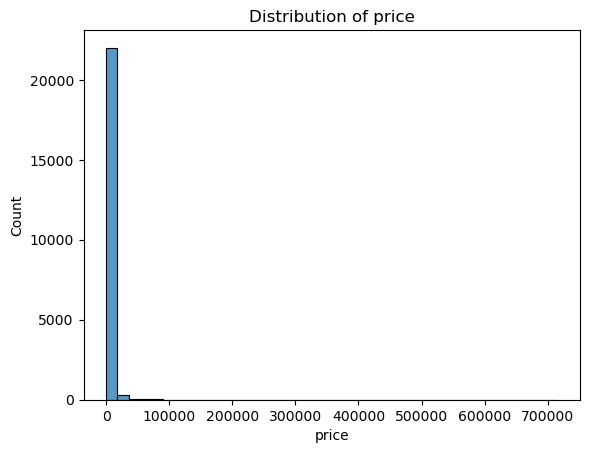

In [9]:
sns.histplot(listing['price'], bins=40)
plt.title('Distribution of price');

**Observation**<br>
My histogram seems a bit wierd, but actually, the data is skewed to the left, meaning, most of the airbnb prices are actually cheap and not expensive.

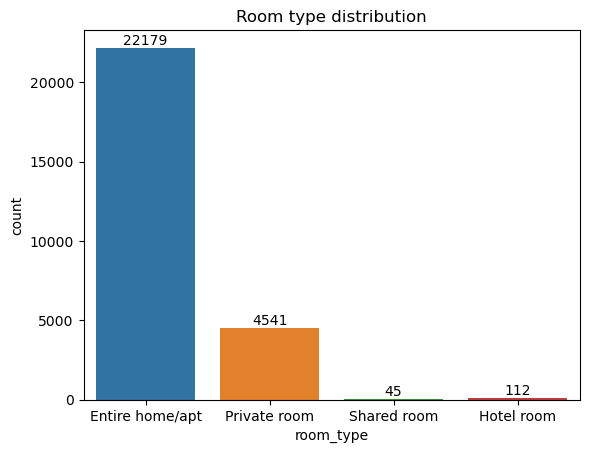

In [10]:
figure, ax = plt.subplots()
sns.countplot(x='room_type', data=listing)
plt.title('Room type distribution')
ax.bar_label(ax.containers[0], label_type = 'edge');

**Observation**<br>
The most common room type sought for by clients is an entire home or apartment by 22179 while the least sought for room is a shared room by 45.

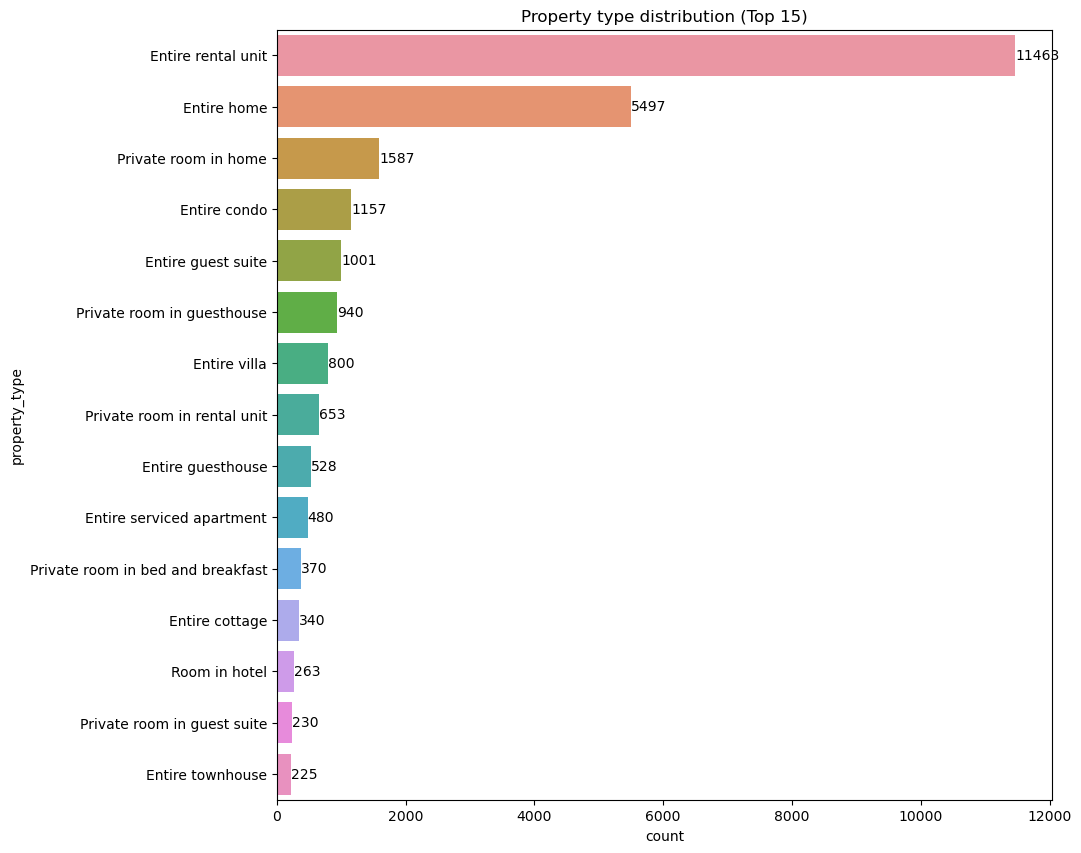

In [11]:
# Distribution of property type
figure, ax = plt.subplots(figsize = (10, 10))
order = listing['property_type'].value_counts().head(15).index
sns.countplot(y='property_type', data=listing, order = order)
plt.title('Property type distribution (Top 15)')
ax.bar_label(ax.containers[0], label_type = 'edge');

**Observation**<br>
From the above plot, entire rental unit is most sought for by clients with 11463 votes followed by entire home with 5497.

In [12]:
# Format the bathroom data. There doesn't exist a 1.5 bathroom 
# Only format the wrong values, leave the nan values as they are
listing['bathrooms'] = listing['bathrooms'].apply(
    lambda x: int(x) if pd.notnull(x) else np.nan
)

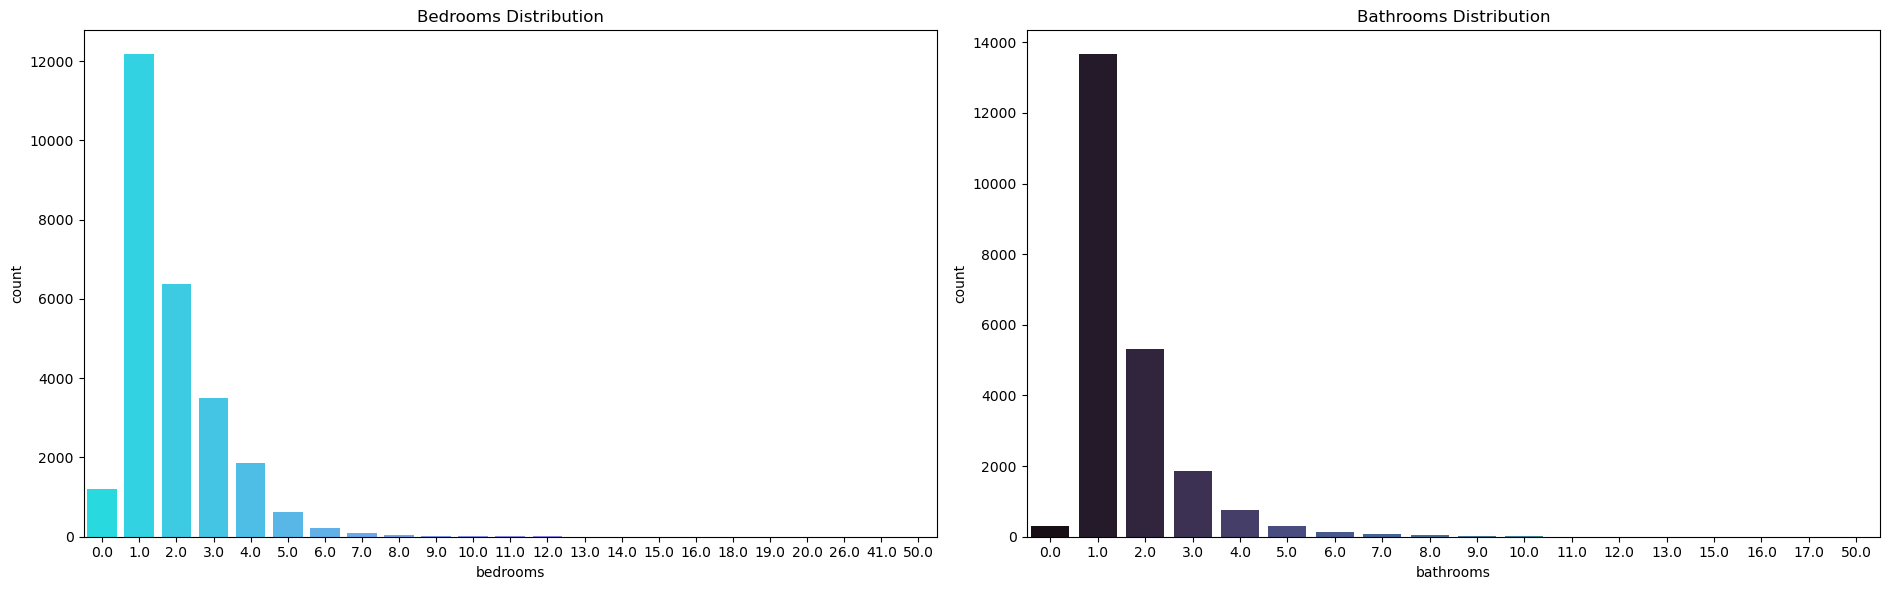

In [13]:
# Distribution of the bedrooms and beds
fig, axes = plt.subplots(1, 2, figsize=(19, 6))
sns.countplot(x='bedrooms', data=listing, ax=axes[0], palette='cool')
sns.countplot(x='bathrooms', data=listing, ax=axes[1], palette='mako')
axes[0].set_title('Bedrooms Distribution')
axes[1].set_title('Bathrooms Distribution')
plt.tight_layout()
plt.show()

**Observation**<br>
Most Airbnbs have 1 to 5 bedrooms and 1 to 4 bathrooms. There are some outliers as seen in the graphs.

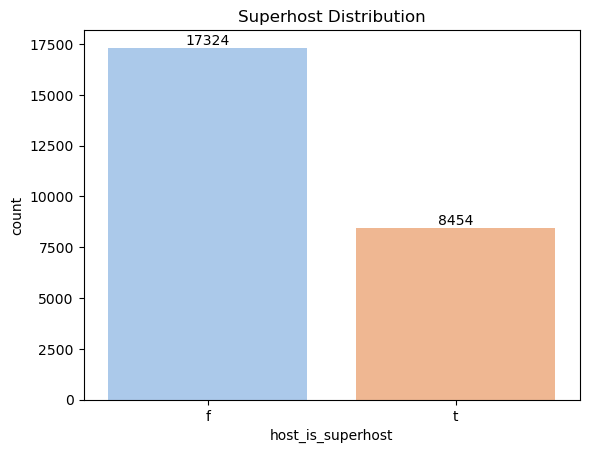

In [14]:
# Distribution of superhosts
figure, ax = plt.subplots()
sns.countplot(x='host_is_superhost', data=listing, palette='pastel')
plt.title('Superhost Distribution')
ax.bar_label(ax.containers[0], label_type = 'edge')
plt.show();

**Observation**<br>
There are few superhosts in Cape Town by 8454.

### Bivariate Analysis

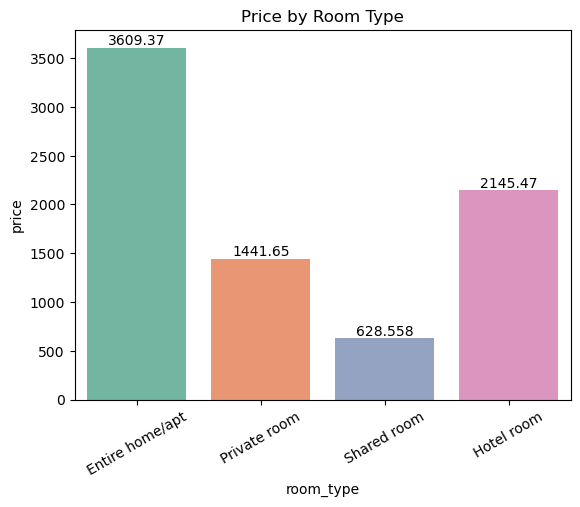

In [15]:
# Room type vs price
figure, ax = plt.subplots()
sns.barplot(x='room_type', y='price', data=listing, palette='Set2', errorbar = None)
plt.title('Price by Room Type')
plt.xticks(rotation=30)
ax.bar_label(ax.containers[0], label_type = 'edge')
plt.show();

**Observation**<br>
The most expensive room is an entire home or apartment for `$3609.37`, while the cheapest room is a shared room for `$628.56`.

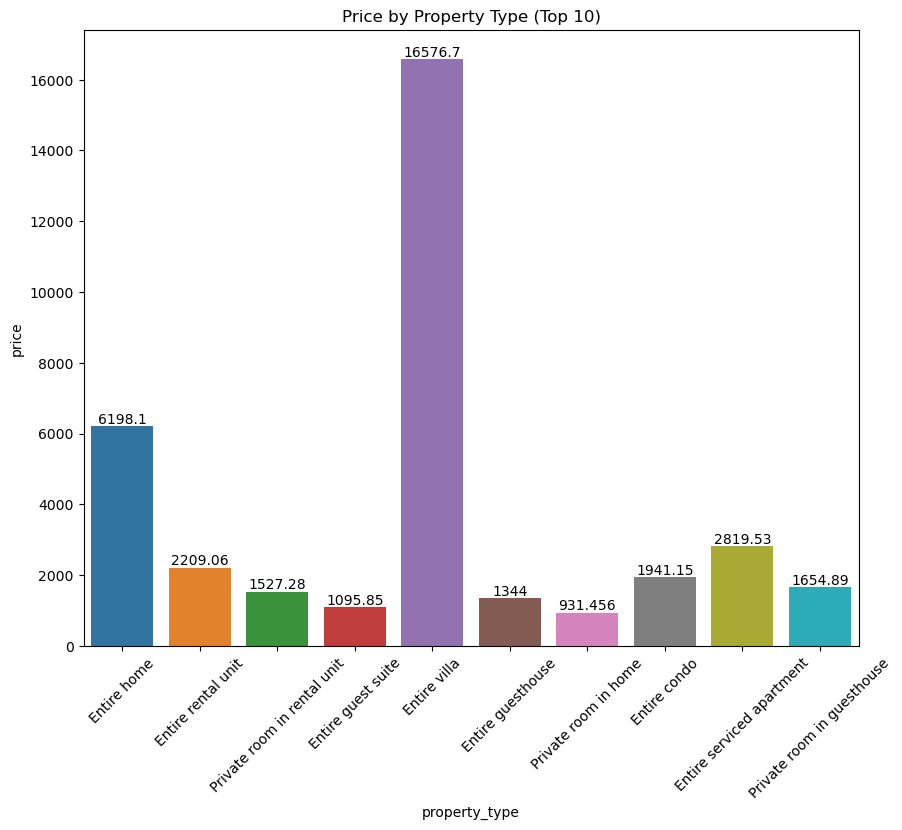

In [16]:
# Property type vs price, top 10
figure, ax = plt.subplots(figsize = (10, 8))
top_props = listing['property_type'].value_counts().head(10).index
sns.barplot(x='property_type', y='price', data=listing[listing['property_type'].isin(top_props)], errorbar = None)
plt.xticks(rotation=45)
plt.title('Price by Property Type (Top 10)')
ax.bar_label(ax.containers[0], label_type = 'edge')
plt.show();

**Observations**<br>
An entire villa is the most expensive property for `$16576.70` followed by an entire home which goes for `$6198.10`.

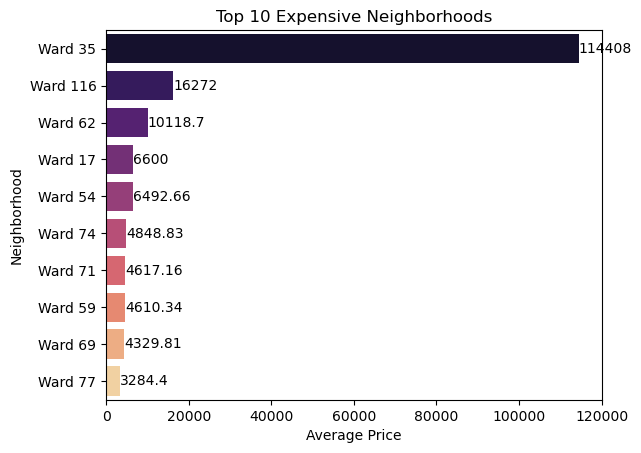

In [17]:
# Neighbourhoods vs price
figure, ax = plt.subplots()
avg_price_neigh = listing.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_price_neigh.values, y=avg_price_neigh.index, palette = 'magma')
plt.title('Top 10 Expensive Neighborhoods')
plt.xlabel('Average Price')
plt.ylabel('Neighborhood')
ax.bar_label(ax.containers[0], label_type = 'edge')
plt.show();

**Observations**<br>
The most expensive neighborhood to stay in is Ward 35, which goes for `$114408`, followed by Ward 116 for `$16272`. Among the top ten most expensive wards, ward 77 is the least costly neighbourhood, going for `$3284,40`.

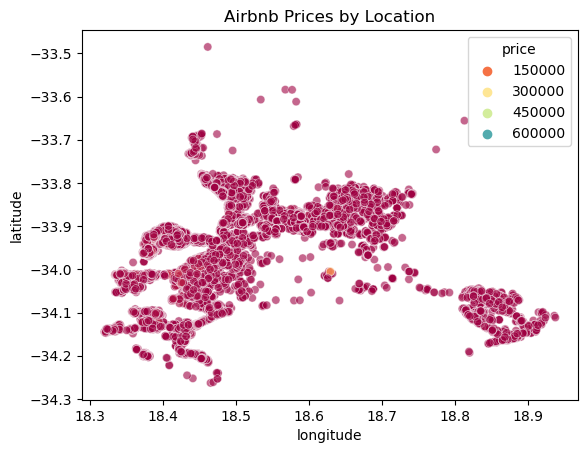

In [18]:
# Prices vs Location
sns.scatterplot(x='longitude', y='latitude', hue='price', data=listing, palette='Spectral', alpha=0.6)
plt.title('Airbnb Prices by Location')
plt.show;

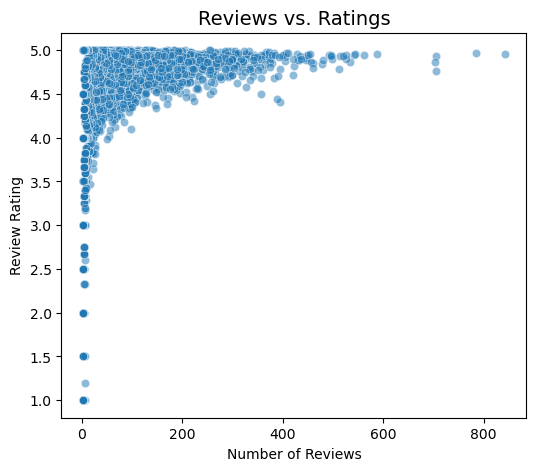

In [19]:
# Reviews vs ratings
fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(x='number_of_reviews', y='review_scores_rating', data=listing, alpha=0.5)
plt.title('Reviews vs. Ratings', fontsize=14)
plt.xlabel('Number of Reviews')
plt.ylabel('Review Rating')
plt.show();

**Observation**<br>
High reviews go hand in hand with high ratings.

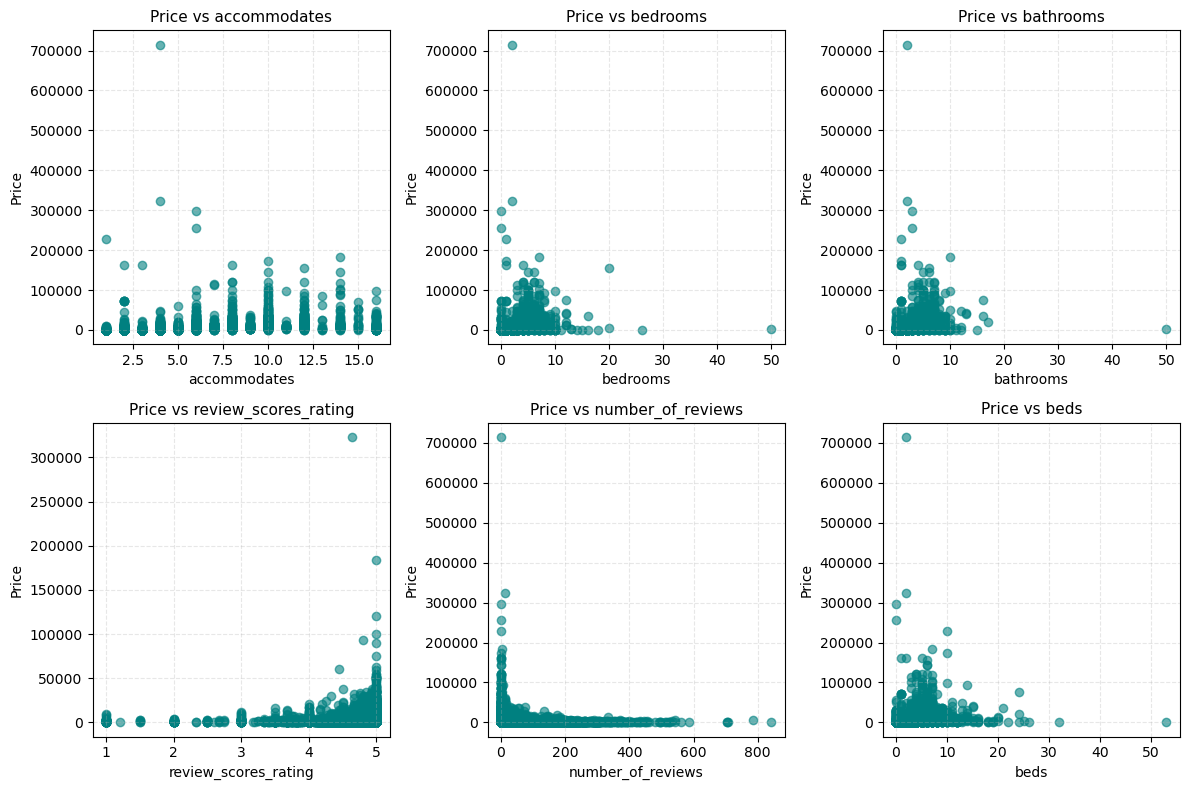

In [20]:
# Select key numerical features for analysis
numerical_features = ['accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating', 'number_of_reviews', 'beds']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot each numerical feature against price
for i, feature in enumerate(numerical_features):
    row, col = i // 3, i % 3
    if feature in listing.columns:
        axes[row, col].scatter(listing[feature], listing['price'], alpha=0.6, color='teal')
        axes[row, col].set_xlabel(feature, fontsize=10)
        axes[row, col].set_ylabel('Price', fontsize=10)
        axes[row, col].set_title(f'Price vs {feature}', fontsize=11)
        axes[row, col].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Observation**<br>
From the above graphs, the relationships are not linear.

# 3. Data Preparation
## 3.1 Data Cleaning
**Purpose:**
 Transform raw data into a clean, structured format suitable for machine learning models through cleaning, feature engineering, and preprocessing.

First, I'll choose the columns that I'll most probably use in achieving my objective, which makes it easier to work in data preparation instead of using the entire dataset.

In [21]:
relevant_columns = ['property_type', 'room_type', 'accommodates', 'amenities', 'bedrooms', 'beds', 'bathrooms', 'latitude', 'longitude', 'neighbourhood_cleansed', 
                   'host_is_superhost', 'host_listings_count', 'host_since', 'host_acceptance_rate', 'availability_365', 'number_of_reviews', 
                   'review_scores_rating', 'instant_bookable', 'review_scores_location', 'price']

In [22]:
df = listing[relevant_columns]
df.head()

,property_type,room_type,accommodates,amenities,bedrooms,beds,bathrooms,latitude,longitude,neighbourhood_cleansed,host_is_superhost,host_listings_count,host_since,host_acceptance_rate,availability_365,number_of_reviews,review_scores_rating,instant_bookable,review_scores_location,price
0,Entire home,Entire home/apt,6,"[""Bathtub"", ""Fire extinguisher"", ""Oven"", ""Port...",3.0,4.0,3.0,-33.800010,18.460630,Ward 23,f,7.0,2009-12-01,88%,230,47,4.81,f,4.94,2315.0
1,Entire rental unit,Entire home/apt,6,"[""Hangers"", ""TV with standard cable"", ""Wifi"", ...",3.0,5.0,2.0,-33.788260,18.459400,Ward 23,NaN,7.0,2009-12-02,33%,264,0,NaN,f,NaN,4785.0
2,Private room in rental unit,Private room,2,"[""Wifi"", ""Oven"", ""Beach essentials"", ""Body soa...",1.0,2.0,1.0,-33.858356,18.490376,Ward 4,f,7.0,2009-12-02,80%,314,7,5.00,f,4.86,1118.0
3,Entire rental unit,Entire home/apt,2,"[""Wifi"", ""Free parking on premises"", ""TV"", ""Wa...",1.0,1.0,1.0,-33.911150,18.412350,Ward 115,NaN,2.0,2009-12-03,NaN,365,2,4.50,f,5.00,2250.0
4,Entire guest suite,Entire home/apt,3,"[""Fire extinguisher"", ""Hangers"", ""Wifi"", ""Free...",2.0,NaN,NaN,-33.830740,18.631420,Ward 112,f,1.0,2009-12-05,NaN,0,0,NaN,f,NaN,NaN


#### 1. Handle missing values

In [23]:
# Check for missing values
df.isna().sum()

property_type                0
room_type                    0
accommodates                 0
amenities                    0
bedrooms                   664
beds                      4228
bathrooms                 4372
latitude                     0
longitude                    0
neighbourhood_cleansed       0
host_is_superhost         1099
host_listings_count          6
host_since                   6
host_acceptance_rate      3930
availability_365             0
number_of_reviews            0
review_scores_rating      6124
instant_bookable             0
review_scores_location    6127
price                     4401
dtype: int64

In [24]:
# Percentages of the missing values
df.isna().sum()*100/len(df)

property_type              0.000000
room_type                  0.000000
accommodates               0.000000
amenities                  0.000000
bedrooms                   2.470514
beds                      15.730922
bathrooms                 16.266696
latitude                   0.000000
longitude                  0.000000
neighbourhood_cleansed     0.000000
host_is_superhost          4.088998
host_listings_count        0.022324
host_since                 0.022324
host_acceptance_rate      14.622168
availability_365           0.000000
number_of_reviews          0.000000
review_scores_rating      22.785281
instant_bookable           0.000000
review_scores_location    22.796443
price                     16.374595
dtype: float64

In [25]:
df = df.dropna(subset = ['bedrooms', 'host_is_superhost', 'host_listings_count', 'host_since'])
df = df.reset_index(drop = True)
df.isna().sum()*100/len(df)

property_type              0.000000
room_type                  0.000000
accommodates               0.000000
amenities                  0.000000
bedrooms                   0.000000
beds                      13.748905
bathrooms                 14.322108
latitude                   0.000000
longitude                  0.000000
neighbourhood_cleansed     0.000000
host_is_superhost          0.000000
host_listings_count        0.000000
host_since                 0.000000
host_acceptance_rate      13.637449
availability_365           0.000000
number_of_reviews          0.000000
review_scores_rating      22.442481
instant_bookable           0.000000
review_scores_location    22.454422
price                     14.334050
dtype: float64

In [26]:
# Handle the missing in host_acceptance_rate
# It's categorical data, so I'll fill the missing values with the mode
df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mode()[0], inplace = True)

In [27]:
df.isna().sum()*100/len(df)

property_type              0.000000
room_type                  0.000000
accommodates               0.000000
amenities                  0.000000
bedrooms                   0.000000
beds                      13.748905
bathrooms                 14.322108
latitude                   0.000000
longitude                  0.000000
neighbourhood_cleansed     0.000000
host_is_superhost          0.000000
host_listings_count        0.000000
host_since                 0.000000
host_acceptance_rate       0.000000
availability_365           0.000000
number_of_reviews          0.000000
review_scores_rating      22.442481
instant_bookable           0.000000
review_scores_location    22.454422
price                     14.334050
dtype: float64

The remaining missing values are floats. I have to determine if the data in those columns are skewed so that I'll known which method to use in order to fill their missing values.

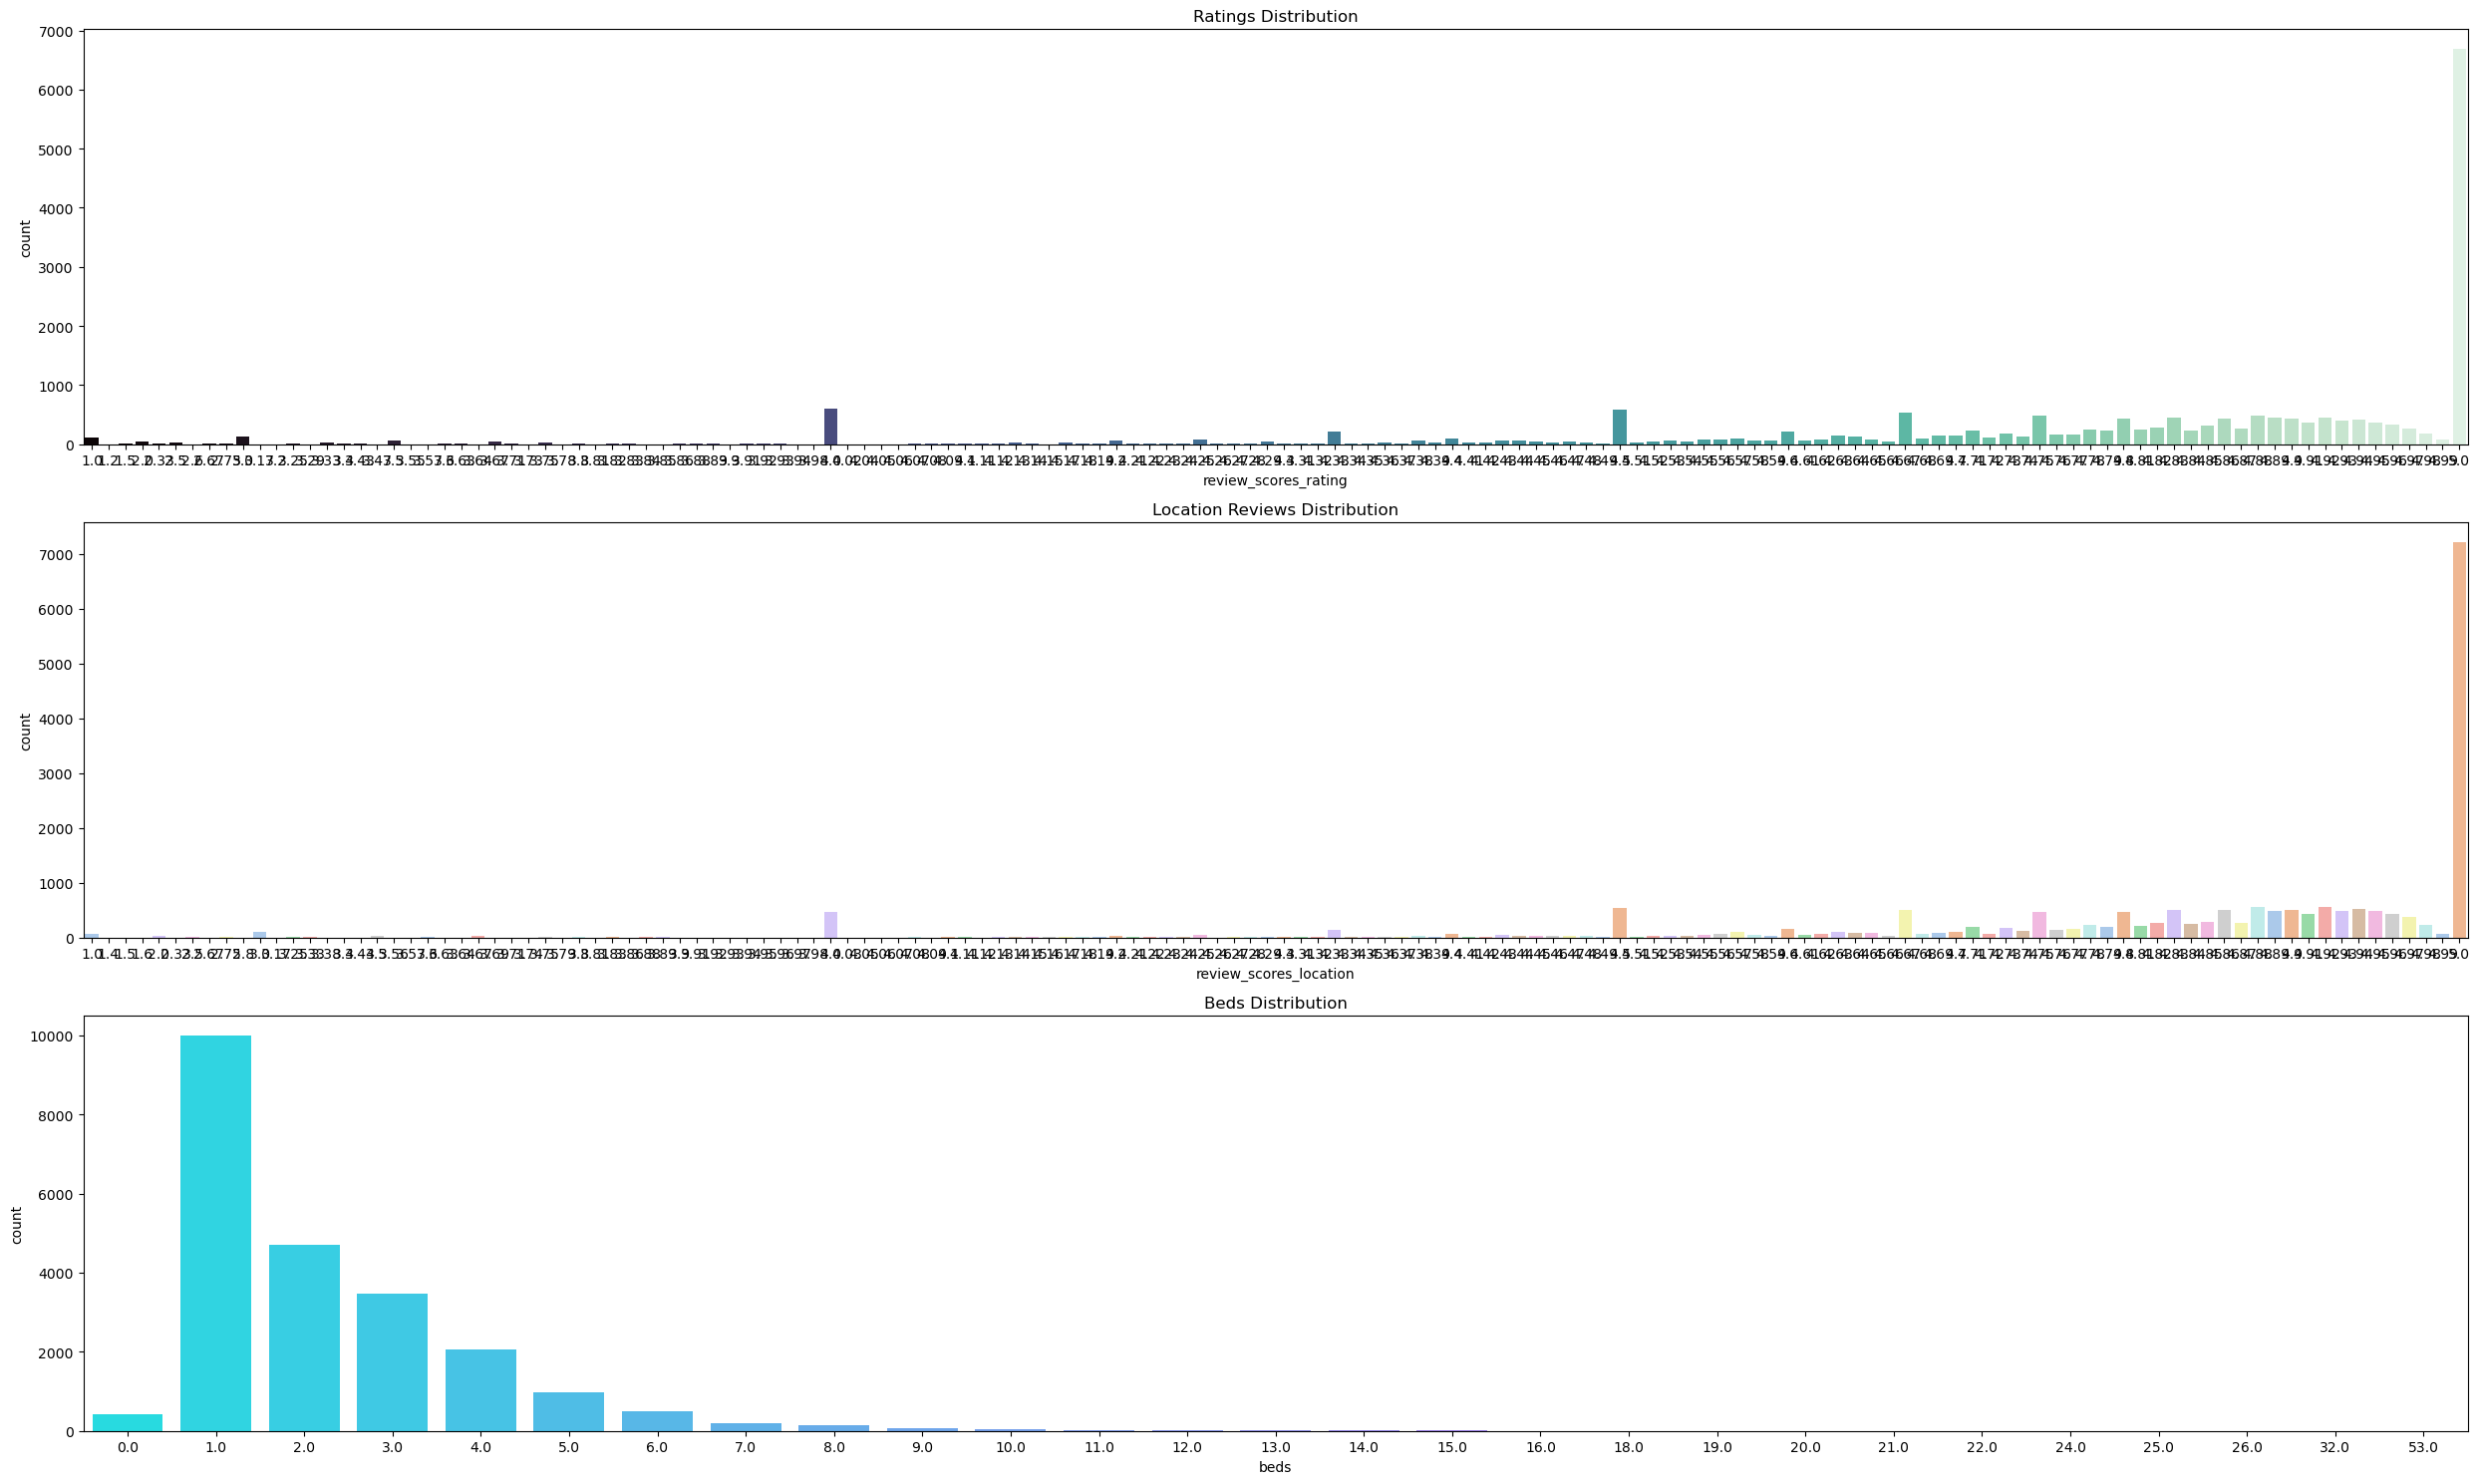

In [28]:
# Checking how the dta is distributed
fig, axes = plt.subplots(3, 1, figsize=(25, 15))
sns.countplot(x='review_scores_rating', data=listing, ax=axes[0], palette='mako')
sns.countplot(x='review_scores_location', data=listing, ax=axes[1], palette='pastel')
sns.countplot(x='beds', data=listing, ax=axes[2], palette='cool')
axes[0].set_title('Ratings Distribution')
axes[1].set_title('Location Reviews Distribution')
axes[2].set_title('Beds Distribution')
plt.tight_layout()
plt.show()

**Observation**<br>
The graphs may not be fully clear due to their large amount, but from what is visible, one can see that rating and location reviews are skewed to the right, while beds is skewed to the left, which means that I'll use the median to fill the missing values. Bathrooms and price underwent some analysis in the data understanding, but they're also skewed to the left.

In [29]:
cols = ['beds', 'review_scores_rating', 'bathrooms', 'review_scores_location', 'price'] 

# Fill the each column with its median
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

In [30]:
df.isna().sum()*100/len(df)

property_type             0.0
room_type                 0.0
accommodates              0.0
amenities                 0.0
bedrooms                  0.0
beds                      0.0
bathrooms                 0.0
latitude                  0.0
longitude                 0.0
neighbourhood_cleansed    0.0
host_is_superhost         0.0
host_listings_count       0.0
host_since                0.0
host_acceptance_rate      0.0
availability_365          0.0
number_of_reviews         0.0
review_scores_rating      0.0
instant_bookable          0.0
review_scores_location    0.0
price                     0.0
dtype: float64

In [31]:
df.dtypes

property_type              object
room_type                  object
accommodates                int64
amenities                  object
bedrooms                  float64
beds                      float64
bathrooms                 float64
latitude                  float64
longitude                 float64
neighbourhood_cleansed     object
host_is_superhost          object
host_listings_count       float64
host_since                 object
host_acceptance_rate       object
availability_365            int64
number_of_reviews           int64
review_scores_rating      float64
instant_bookable           object
review_scores_location    float64
price                     float64
dtype: object

#### 2. Standardizing formats.
Some features such as bedrooms need to be well formatted. For this example, bedrooms are not calculated by floats, is, half a bedroom (2.5), so I need to change it to an integer.

In [32]:
# Change the below columns from floats to integers
format_cols = ['bedrooms', 'beds', 'bathrooms']

df[format_cols] = df[format_cols].astype('int64')

In [33]:
df.dtypes

property_type              object
room_type                  object
accommodates                int64
amenities                  object
bedrooms                    int64
beds                        int64
bathrooms                   int64
latitude                  float64
longitude                 float64
neighbourhood_cleansed     object
host_is_superhost          object
host_listings_count       float64
host_since                 object
host_acceptance_rate       object
availability_365            int64
number_of_reviews           int64
review_scores_rating      float64
instant_bookable           object
review_scores_location    float64
price                     float64
dtype: object

### 3. Dealing with outliers

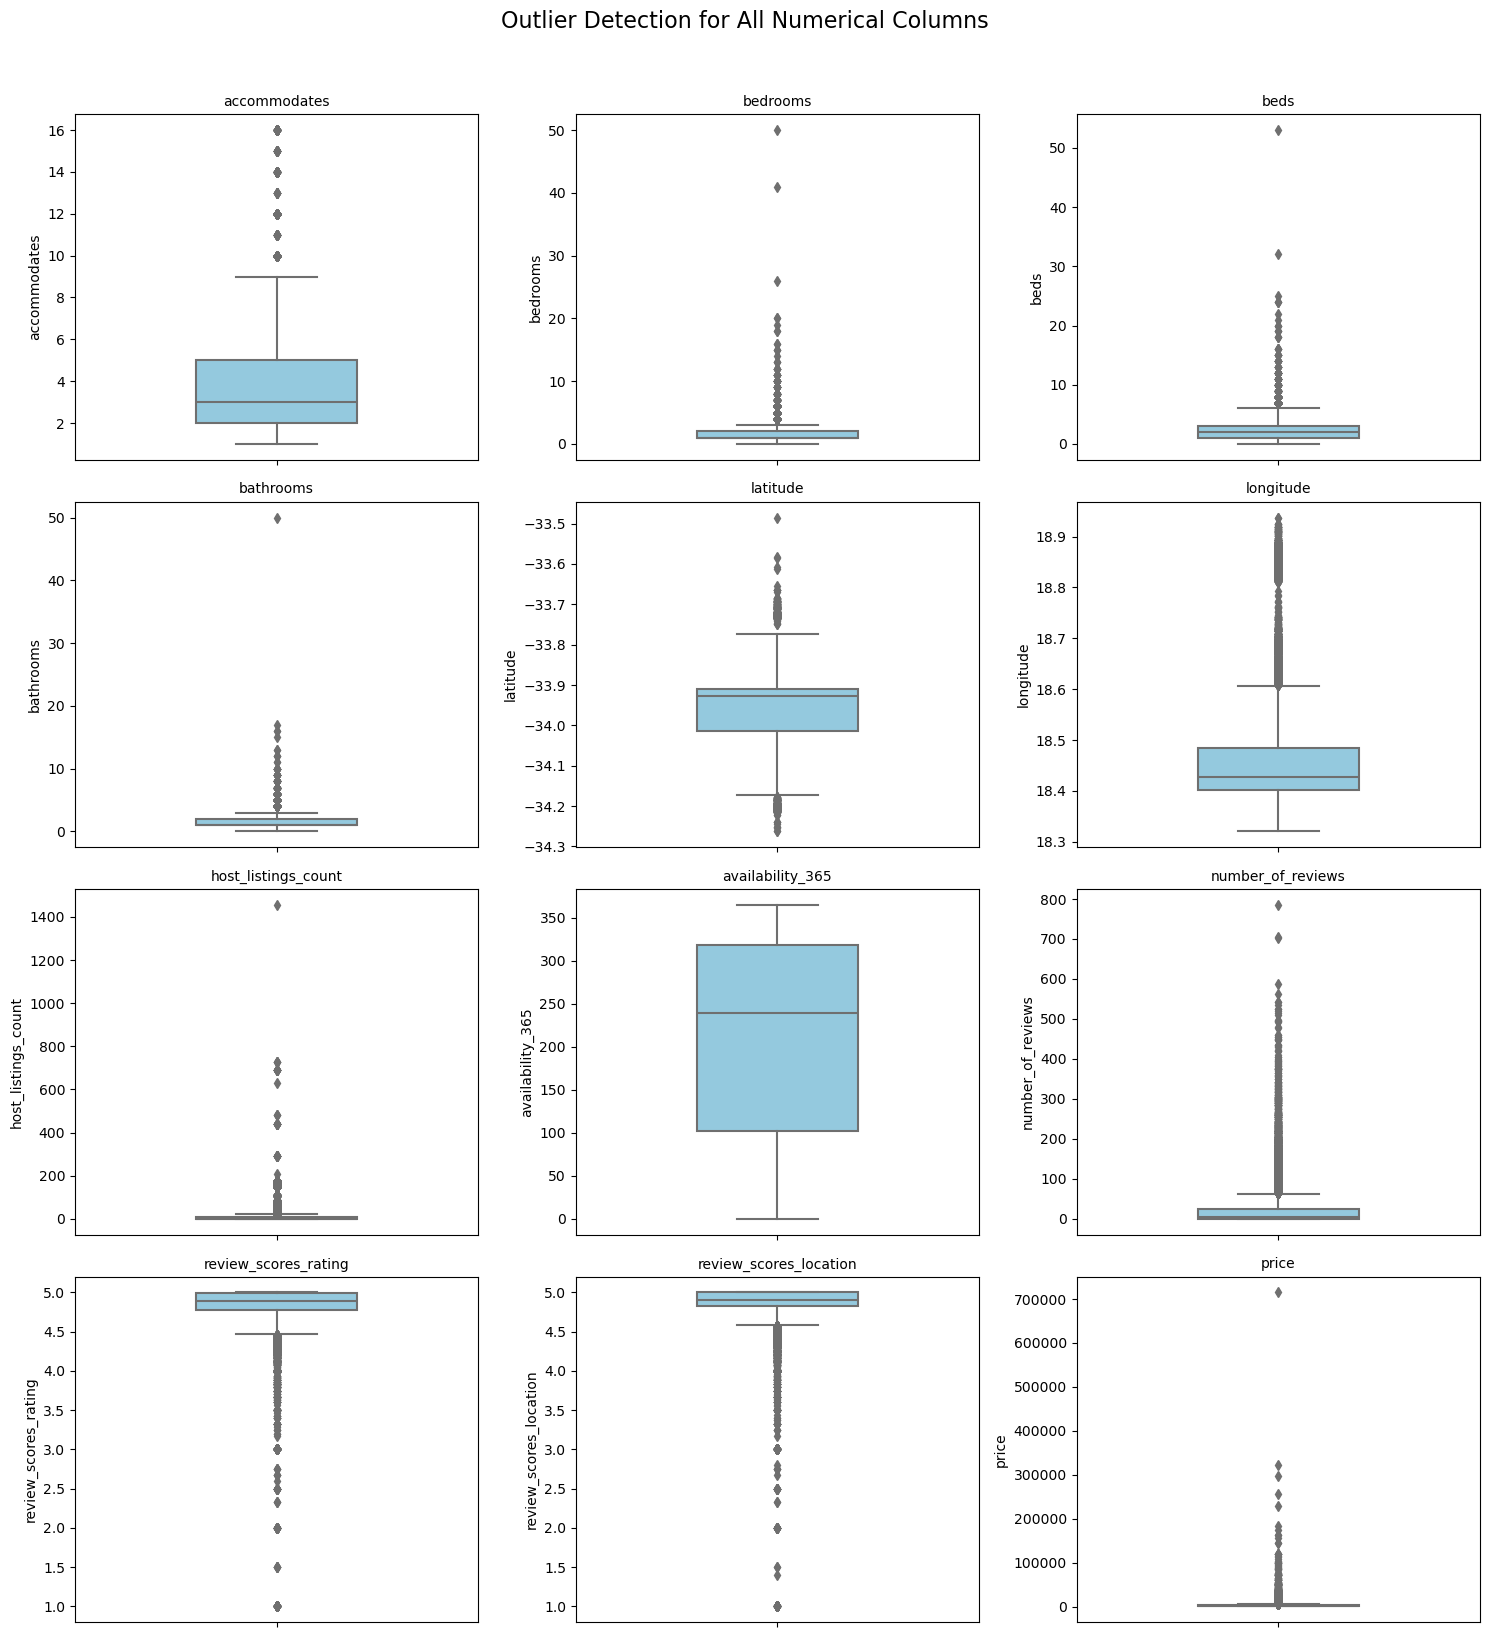

In [34]:
# Select only numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Set figure size dynamically based on number of columns
n_cols = 3  # number of plots per row
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(15, n_rows * 4))
plt.suptitle('Outlier Detection for All Numerical Columns', fontsize=16, y=1.02)

# Create a boxplot for each numeric column
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='skyblue', width=0.4)
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.tight_layout()

plt.show()

**Observation**<br>
There are several outliers in each column.

In [35]:
# Statistical summary of price column
df['price'].describe()

count     25122.000000
mean       3020.112093
std        8451.255039
min         180.000000
25%        1027.000000
50%        1517.000000
75%        2565.000000
max      714885.000000
Name: price, dtype: float64

In [36]:
# Check for the percentages of the outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of data that are outliers: {len(outliers) / len(df) * 100:.2f}%")


Number of outliers: 3019
Percentage of data that are outliers: 12.02%


In [37]:
# Check some of the outliers and see if they are genuine outliers or mistakes made, eg, in inputting data.
outliers.sort_values(by='price', ascending=False).head(10)

,property_type,room_type,accommodates,amenities,bedrooms,beds,bathrooms,latitude,longitude,neighbourhood_cleansed,host_is_superhost,host_listings_count,host_since,host_acceptance_rate,availability_365,number_of_reviews,review_scores_rating,instant_bookable,review_scores_location,price
23570,Entire rental unit,Entire home/apt,4,"[""Building staff"", ""Room-darkening shades"", ""C...",2,2,2,-33.977600,18.459060,Ward 59,f,3.0,2025-06-18,100%,0,0,4.89,f,4.91,714885.0
2116,Entire rental unit,Entire home/apt,4,"[""Fire extinguisher"", ""Wifi"", ""Portable fans"",...",2,2,2,-34.016040,18.428610,Ward 62,f,4.0,2015-11-27,100%,356,11,4.64,f,5.00,323000.0
18950,Entire villa,Entire home/apt,6,"[""TV with standard cable"", ""Wifi"", ""Backyard"",...",0,0,3,-33.927806,18.376967,Ward 54,f,727.0,2022-03-14,47%,363,0,4.89,f,4.91,297812.0
18951,Entire villa,Entire home/apt,6,"[""TV with standard cable"", ""Wifi"", ""Backyard"",...",0,0,3,-33.929303,18.378039,Ward 54,f,727.0,2022-03-14,47%,363,0,4.89,f,4.91,255267.0
21390,Entire rental unit,Entire home/apt,1,"[""Wifi"", ""Breakfast"", ""TV"", ""Washer"", ""Essenti...",1,10,1,-34.004482,18.629428,Ward 35,f,4.0,2018-10-04,100%,239,0,4.89,t,4.91,228467.0
20194,Entire villa,Entire home/apt,14,"[""Dedicated workspace"", ""Exercise equipment: f...",7,7,10,-33.934064,18.379795,Ward 54,f,1.0,2022-10-30,57%,298,2,5.00,f,5.00,184000.0
21391,Entire rental unit,Entire home/apt,10,"[""Wifi"", ""Breakfast"", ""TV"", ""Washer"", ""Essenti...",1,10,1,-34.005569,18.629417,Ward 116,f,4.0,2018-10-04,100%,239,0,4.89,t,4.91,173866.0
22239,Entire rental unit,Entire home/apt,2,"[""Bathtub"", ""Wifi"", ""Oven"", ""Washer \u2013\u00...",1,1,1,-34.067860,18.834541,Ward 15,f,481.0,2025-03-21,44%,123,0,4.89,f,4.91,162471.0
22238,Entire home,Entire home/apt,8,"[""Bathtub"", ""Wifi"", ""Oven"", ""Backyard"", ""Toast...",4,5,4,-34.037975,18.436063,Ward 62,f,481.0,2025-03-21,44%,90,0,4.89,f,4.91,162471.0
4361,Entire villa,Entire home/apt,12,"[""Bathtub"", ""Fire extinguisher"", ""Wifi"", ""Heat...",20,6,6,-33.933210,18.379930,Ward 54,f,4.0,2019-07-19,57%,55,0,4.89,t,4.91,156000.0


**Observation**<br>
Some of the outliers are not genuine while others are. How can an entire villa or home not have any bedrooms but have 10 beds, this is a good example of a non-genuine outlier. An example of a genuine outlier is 4 accommodates, 2 bedrooms, 2 beds and 2 bathrooms.

Capped extreme 1% outliers: prices below 1027.00 set to lower cap, above 25877.69 set to upper cap.


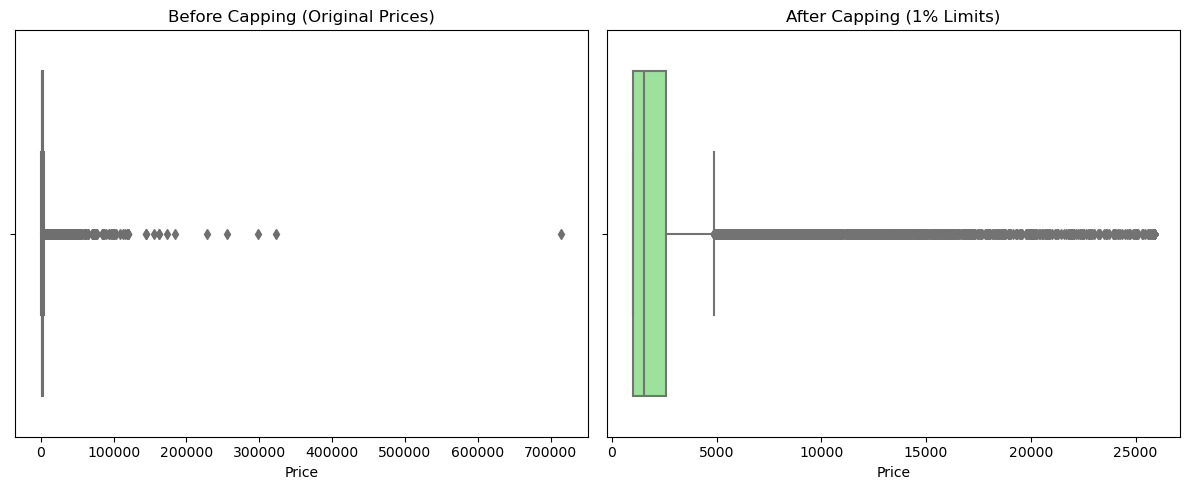

In [38]:
# Visualize original price distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Before Capping (Original Prices)')
plt.xlabel('Price')

# Cap extreme 1% outliers
lower_cap = df['price'].quantile(0.25)
upper_cap = df['price'].quantile(0.99)

df['price'] = np.where(
    df['price'] < lower_cap, lower_cap,
    np.where(df['price'] > upper_cap, upper_cap, df['price'])
)

print(f"Capped extreme 1% outliers: prices below {lower_cap:.2f} set to lower cap, above {upper_cap:.2f} set to upper cap.")

# Visualize capped prices
plt.subplot(1,2,2)
sns.boxplot(x=df['price'], color='lightgreen')
plt.title('After Capping (1% Limits)')
plt.xlabel('Price')

plt.tight_layout()
plt.show()


In [39]:
# Remove outliers for the rest of the other numerical columns
outlier_columns = ['accommodates', 'bedrooms', 'bathrooms', 'beds']

for col in outlier_columns:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers before capping
        outliers_high = (df[col] > upper_bound).sum()
        outliers_low = (df[col] < lower_bound).sum()
        total_outliers = outliers_high + outliers_low
        
        # Cap outliers instead of removing to preserve data
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        
        print(f"{col}: {total_outliers} outliers capped using the IQR method")

accommodates: 947 outliers capped using the IQR method
bedrooms: 2829 outliers capped using the IQR method
bathrooms: 1312 outliers capped using the IQR method
beds: 533 outliers capped using the IQR method


Capping was chosen instead of removal since some extreme prices might be real Airbnb listings, and deleting them could mean losing useful information.

**Benefits**
- **Data preservation:** No observations are removed, maintaining the dataset’s integrity.
- **Improved model stability:** Reduces the influence of extreme values on model training.
- **Enhanced reliability:** Produces a more balanced distribution of data without introducing bias.

### 4. Handling placeholders.

In [40]:
# Check for placeholders in the values of each column
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

property_type: ['Entire home' 'Private room in rental unit' 'Entire guest suite'
 'Entire rental unit' 'Entire villa' 'Entire guesthouse' 'Entire loft'
 'Private room in home' 'Private room in guest suite' 'Entire place'
 'Private room in cottage' 'Entire condo' 'Entire cottage'
 'Private room in villa' 'Entire serviced apartment'
 'Private room in guesthouse' 'Entire townhouse' 'Private room in loft'
 'Private room in townhouse' 'Private room in condo'
 'Private room in bed and breakfast' 'Room in boutique hotel'
 'Entire bungalow' 'Tiny home' 'Room in bed and breakfast'
 'Private room in serviced apartment' 'Room in aparthotel'
 'Private room in hostel' 'Entire cabin' 'Shared room in rental unit'
 'Private room in bungalow' 'Entire chalet' 'Private room'
 'Shared room in home' 'Earthen home' 'Room in serviced apartment'
 'Room in guesthouse' 'Private room in farm stay' 'Shared room in loft'
 'Entire vacation home' 'Entire resort' 'Tower' 'Bus' 'Room in hostel'
 'Farm stay' 'Room in h

**Observation**<br>
No placeholders found after going through each columns and its unique values.

## 3.2 Feature Engineering

### 3.2.1 Geospatial Features

In [41]:
# Define the Haversine distance function, to make the distance calculated in kilometers.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Define major Cape Town landmarks
landmarks = {
    'table_mountain': (-33.9628, 18.4099),
    'v_a_waterfront': (-33.9056, 18.4218),
    'camps_bay': (-33.9508, 18.3786),
    'clifton_beach': (-33.9375, 18.3800),
    'city_center': (-33.9258, 18.4232)
}

# Calculate distance (in km) from each landmark
for name, (lat, lon) in landmarks.items():
    df[f'distance_from_{name}'] = haversine(df['latitude'], df['longitude'], lat, lon)

**Purpose:** To capture the effect of location on listing prices by calculating the distance(km) of each Airbnb property from major Cape Town landmarks.

### 3.2.2 Temporal Features

In [42]:
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_days'] = (pd.Timestamp.now() - df['host_since']).dt.days
df['hosting_years'] = df['host_days'] / 365

**Purpose:** Older (more experienced) hosts tend to have more reliable listings and may charge higher prices.

### 3.2.3 Amenity Features

In [43]:
# Define a list of important (premium) amenities that may affect listing price
premium_amenities = [
    'Pool', 'Hot tub', 'Gym', 
    'BBQ grill', 'Ocean view', 'Wifi', 'Parking'
]

# Create a new binary column for each amenity (1 = has it, 0 = doesn't)
for amenity in premium_amenities:
    col_name = f'has_{amenity.lower().replace(" ", "_")}'
    df[col_name] = df['amenities'].astype(str).str.contains(amenity, case=False, na=False).astype('int64')

# Count how many total amenities each listing has
df['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)

**Purpose:** Captures presence of high-value amenities and the overall richness of a listing’s amenities.

### 3.2.4 Host Experience

In [44]:
# Convert acceptance rate from string (%) to numeric
df['host_acceptance_rate'] = (
    df['host_acceptance_rate'].astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

# Map host_is_superhost (t/f) to numeric
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})

**Purpose:** Represents how responsive and reliable the host is. Superhosts with high acceptance rates tend to attract more bookings.

## 3.3 Feature Selection

### Approach
For selecting the most relevant predictors, I'll use **correlation analysis** to identify numerical features that are strongly related to the target variable, `price_capped`. This helps focus on variables that have the greatest impact on pricing. But first, I have to log tranform the target variable. `price`, in order to reduce skewness.

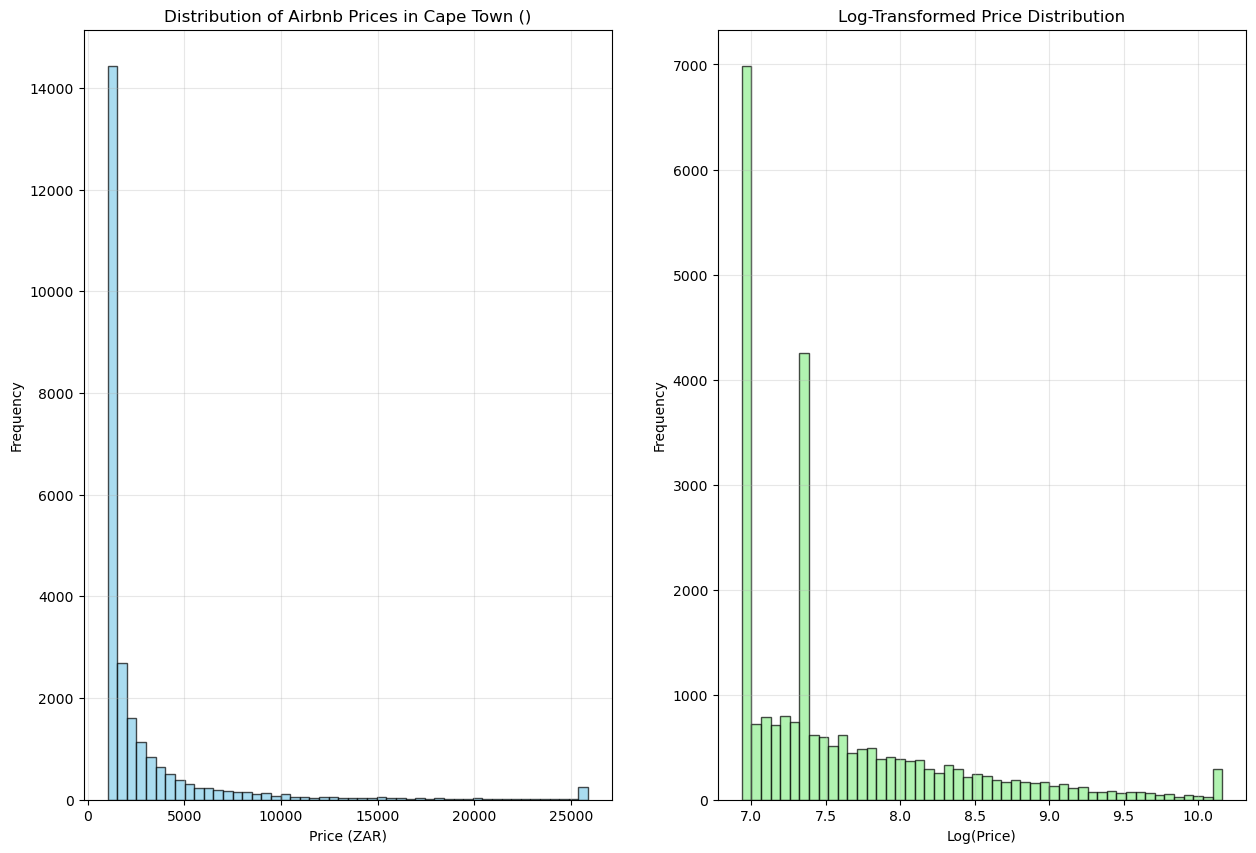

In [45]:
# Log-transform the target variable
df['log_price'] = np.log1p(df['price'])  # log(1 + price) to handle zero values

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
# Original price distribution
axes[0].hist(df['price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Airbnb Prices in Cape Town ()')
axes[0].set_xlabel('Price (ZAR)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Log transformation for normality
axes[1].hist(df['log_price'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

**Obseravtion**<br>
After log transformation, the data looks a bit more distributed.

In [46]:
target_col = 'log_price'  

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlations with the target
correlations = numeric_df.corr(numeric_only=True)[target_col].sort_values(ascending=False)
# Display top correlated features
print("Top correlated features with target:\n")
print(correlations)

Top correlated features with target:

log_price                       1.000000
price                           0.882985
bathrooms                       0.725862
accommodates                    0.678949
bedrooms                        0.632725
beds                            0.616638
has_pool                        0.314520
has_bbq_grill                   0.261251
amenities_count                 0.253847
has_ocean_view                  0.166561
has_hot_tub                     0.135239
review_scores_location          0.127245
hosting_years                   0.122770
host_days                       0.122770
review_scores_rating            0.109751
host_listings_count             0.106557
has_parking                     0.078405
has_gym                         0.043570
has_wifi                        0.038343
availability_365                0.017868
host_is_superhost               0.013172
distance_from_v_a_waterfront   -0.060234
distance_from_city_center      -0.076242
host_acceptance_rat

In [47]:
# The final columns to use in achieving the objective
selected_features = [
    # Property characteristics
    'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    
    # Location Features
    'neighbourhood_cleansed', 'latitude', 'longitude',
    'dist_to_table_mountain', 'dist_to_v_a_waterfront'
    
    # Host Factors
    'host_is_superhost', 'host_listings_count',
    'host_acceptance_rate', 'hosting_years',
    
    # Review 
    'review_scores_rating', 'review_scores_location',
    
    # Amenities
    'amenities_count', 'has_pool',
    'has_bbq_grill', 'has_ocean_view', 'has_hot_tub',
    
    # Availability
    'instant_bookable'
]

# Filter to only include features that exist in our dataframe
available_features = [f for f in selected_features if f in df.columns]
print(f"Selected {len(available_features)} features for modeling:")
for feature in available_features:
    print(f"  • {feature}")

Selected 20 features for modeling:
  • property_type
  • room_type
  • accommodates
  • bedrooms
  • beds
  • bathrooms
  • neighbourhood_cleansed
  • latitude
  • longitude
  • host_listings_count
  • host_acceptance_rate
  • hosting_years
  • review_scores_rating
  • review_scores_location
  • amenities_count
  • has_pool
  • has_bbq_grill
  • has_ocean_view
  • has_hot_tub
  • instant_bookable


## 3.4 Data Preprocessing

**Preprocessing Tasks:**
- **Numerical**: Scale features to similar ranges
- **Categorical**: Convert to vcategorical features to numerical representations
- **Target Variable**: Log-transform price to handle skewness

In [48]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [49]:
# Define the new features and target
X = df[available_features].copy() # Features
y = df['log_price'] # New target variable after log transformation
print(f"Features shape: {X.shape}")
print(f"Target variable: price (length = {len(y)})")

Features shape: (25122, 20)
Target variable: price (length = 25122)


The dataset will be split into **training**, **validation**, and **testing** sets. The training set will be used to fit the models, the validation set will guide model selection, and the testing set will be used in evaluation of the final model.

In [50]:
# Split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split remaining 80% into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)  # 0.25 * 0.8 = 0.2 of original data

In [51]:
# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 4. Modelling

I've decided to work with 5 models:

**Linear Regression:** A simple model that assumes a linear relationship between input features and the target. It’s fast, easy to interpret, and serves as a good starting point for comparison.

**Decision Tree:** A tree-based model that splits data into branches based on feature values. It captures non-linear relationships and is easy to visualize and understand.

**Random Forest:** An ensemble of multiple decision trees that improves accuracy and reduces overfitting. It’s robust and performs well on complex datasets.

**XGBoost:** An advanced gradient boosting model that builds trees sequentially, learning from previous mistakes. It’s efficient, powerful, and often achieves high predictive performance.

**Gradient Boosting:** A powerful ensemble technique that builds trees sequentially, where each tree learns from the errors of the previous ones. It’s effective for capturing complex patterns and delivers strong predictive performance.

In [52]:
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Calculate metrics (on log scale)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    
    # Convert back to original price scale for interpretation
    y_train_actual = np.expm1(y_train)
    y_train_pred_actual = np.expm1(y_train_pred)
    y_val_actual = np.expm1(y_val)
    y_val_pred_actual = np.expm1(y_val_pred)
    
    # Calculate MAPE on actual prices
    val_mape = np.mean(np.abs((y_val_actual - y_val_pred_actual) / y_val_actual)) * 100    
    
    return {
        'model_name': model_name,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'val_mape': val_mape,
        'model': model
    }

In [53]:
# Pipelines for the models
pipe_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('Linclf', LinearRegression())
])

pipe_2 = Pipeline([
    ('preprocessor', preprocessor),
    ( "Decision Tree", DecisionTreeRegressor(random_state=42, max_depth = 7))
])

pipe_3 = Pipeline([
    ('preprocessor', preprocessor),
    ('Random', RandomForestRegressor(random_state = 42, n_estimators=2000, max_depth = 7))
])

pipe_4 = Pipeline([
    ('preprocessor', preprocessor),
    ('XGBoost', XGBRegressor(n_estimators=2000, random_state=42))
])
pipe_5 = Pipeline([
    ('preprocessor', preprocessor),
    ('Gradient', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest',  'XGBoost Regressor', 'Gradient Boosting']
pipe_list = [pipe_1, pipe_2, pipe_3, pipe_4, pipe_5]
# Fit all models
for name, estimator in zip(model_names, pipe_list):
    print(f"Fitting {name} ...")
    estimator.fit(X_train, y_train)

Fitting Linear Regression ...
Fitting Decision Tree ...
Fitting Random Forest ...
Fitting XGBoost Regressor ...
Fitting Gradient Boosting ...


In [54]:
results_list = []

for name, model in zip(model_names, pipe_list):
    print(f"\nEvaluating {name}...")
    
    result = evaluate_model(
        model,
        X_train,
        X_val,
        y_train,
        y_val,
        model_name=name
    )
    
    results_list.append(result)
    
    # Print metrics immediately
    print(f"Validation Metrics for {name}:")
    print(f"   RMSE: {result['val_rmse']:.4f}")
    print(f"   R2: {result['val_r2']:.4f}")
    print(f"   MAPE: {result['val_mape']:.2f}%")

# Create results DataFrame
baseline_df = pd.DataFrame(results_list)
print("\nBASELINE MODEL PERFORMANCE:")
display(baseline_df[['model_name', 'val_rmse', 'val_r2', 'val_mape']].round(4))

# Identify best model
best_baseline = baseline_df.loc[baseline_df['val_r2'].idxmax()]
print(f"\nBEST BASELINE MODEL: {best_baseline['model_name']}")
print(f"   Validation R2: {best_baseline['val_r2']:.4f}")
print(f"   Validation RMSE: {best_baseline['val_rmse']:.4f}")
print(f"   MAPE: {best_baseline['val_mape']:.2f}%")


Evaluating Linear Regression...
Validation Metrics for Linear Regression:
   RMSE: 11396243.2617
   R2: -248664552725744.8438
   MAPE: inf%

Evaluating Decision Tree...
Validation Metrics for Decision Tree:
   RMSE: 0.4183
   R2: 0.6650
   MAPE: 30.80%

Evaluating Random Forest...


C:\Users\USER\AppData\Local\Temp\ipykernel_15192\3759632471.py:18: RuntimeWarning: overflow encountered in expm1
  y_val_pred_actual = np.expm1(y_val_pred)


Validation Metrics for Random Forest:
   RMSE: 0.3923
   R2: 0.7054
   MAPE: 28.42%

Evaluating XGBoost Regressor...
Validation Metrics for XGBoost Regressor:
   RMSE: 0.3555
   R2: 0.7581
   MAPE: 25.95%

Evaluating Gradient Boosting...
Validation Metrics for Gradient Boosting:
   RMSE: 0.3762
   R2: 0.7290
   MAPE: 27.41%

BASELINE MODEL PERFORMANCE:


,model_name,val_rmse,val_r2,val_mape
0,Linear Regression,1.139624e+07,-2.486646e+14,inf
1,Decision Tree,4.183000e-01,6.650000e-01,30.8007
2,Random Forest,3.923000e-01,7.054000e-01,28.4230
3,XGBoost Regressor,3.555000e-01,7.581000e-01,25.9522
4,Gradient Boosting,3.762000e-01,7.290000e-01,27.4097



BEST BASELINE MODEL: XGBoost Regressor
   Validation R2: 0.7581
   Validation RMSE: 0.3555
   MAPE: 25.95%


### **Insights**
**1. Linear Regressor**<br>
These numbers are clearly off the charts. This model failed.
- **R2** = -248664552725744.8438 means my model performs worse than predicting the mean of the target variable.
In other words, my predictions are way off from the actual values.
- **RMSE** is huge, showing massive prediction errors.
- **MAPE**(Mean Absolute Percentage Error) = inf% happens when a model predicts values that lead to division by zero or extremely small actual values (because MAPE divides by actual values).

**2. Decision Tree Regressor**

- **R² = 0.6650:** The model explains about 67% of the variance in my validation data.
- **RMSE = 0.4183:** The typical error is about 0.42 (if the target is log-transformed, this means roughly ±42% in the original scale).
- **MAPE = 30.80%:** On average, predictions are 30% off from actual values.

**Conclusion:** A reasonable baseline. The model is learning, but not very precisely. Decision Trees tend to overfit slightly, but still perform decently without tuning.

**3. Random Forest Regressor**

- **R2 = 0.7054:** Explains about 71% of the variation — better than the Decision Tree.
- **RMSE = 0.3923:** Moderate error, meaning predictions are fairly close to actual values.
- **MAPE = 28.42%:** The average prediction error has dropped, so accuracy has improved.

**Conclusion:** A good improvement. This ensemble model generalizes better and captures nonlinear patterns well. It’s robust and shows solid performance.ell.

**4. XGBoost Regressor**

- **R2 = 0.7581:** Explains about 76% of the variance, which is the best among all models.
- **RMSE = 0.3555:** Lowest error, meaning the predictions are closest to actual values.
- **MAPE = 25.95%:** On average, predictions are about 26% off from actual values.

**Conclusion:** This is my best-performing model. It demonstrates strong predictive power, efficiently handling feature interactions and nonlinearities. XGBoost stands out as the most accurate and reliable baseline model.

**5. Gradient Boosting Regressor**

- **R2 = 0.7290:** The model explains about 73% of the variation in the data, meaning it captures most patterns but still misses some.
- **RMSE = 0.3762:** Moderate error, predictions are fairly close to the actual values.
- **MAPE = 27.41%:** On average, predictions are about 27% off from the true values.

**Conclusion:** The Gradient Boosting model performs reasonably well, showing good predictive power. However, it’s slightly less accurate than XGBoost. With some fine-tuning or better feature selection, it could potentially match or exceed XGBoost’s performance.

### **Hyperparameter Tuning**

#### **1. XGBoost Regressor**

I used **RandomizedSearchCV** because it is faster and more efficient than GridSearchCV, especially when working with a large dataset like mine. It helps find the best hyperparameters without exhaustively searching all combinations.

**Process Overview**

- **Search Method:** RandomizedSearchCV
- **Number of Parameter Combinations Tested:** 50
- **Cross-Validation Folds:** 5
- **Total Fits:** 250 (50 candidates × 5 folds)
- **Evaluation Metric:** Root Mean Squared Error (RMSE)

In [55]:
# Import the necessary libraries
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Parameters for random search
param_dist = {
    'XGBoost__n_estimators': randint(100, 500),
    'XGBoost__learning_rate': uniform(0.01, 0.2),
    'XGBoost__max_depth': randint(3, 10),
    'XGBoost__subsample': uniform(0.7, 0.3),
    'XGBoost__colsample_bytree': uniform(0.7, 0.3),
    'XGBoost__reg_lambda': uniform(0, 2),  # L2 regularization
    'XGBoost__reg_alpha': uniform(0, 1)    # L1 regularization
}

In [56]:
# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipe_4,
    param_distributions=param_dist,
    n_iter=50,            
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
# Fit to training data
random_search.fit(X_train, y_train)

# Display the best parameters and best RMSE
print("Best Parameters:", random_search.best_params_)
print("Best RMSE:", (-random_search.best_score_)**0.5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'XGBoost__colsample_bytree': 0.7076257380232285, 'XGBoost__learning_rate': 0.031578285398660894, 'XGBoost__max_depth': 9, 'XGBoost__n_estimators': 451, 'XGBoost__reg_alpha': 0.6364104112637804, 'XGBoost__reg_lambda': 0.6287119621526533, 'XGBoost__subsample': 0.8525712073494107}
Best RMSE: 0.33008077273561864


In [57]:
# Evaluate R² on validation/test data
best_gbr = random_search.best_estimator_
y_pred = best_gbr.predict(X_val)
r2 = r2_score(y_val, y_pred)

print("Validation R2:", r2)

Validation R2: 0.7825915320095362


### Best Hyperparameters

- **colsample_bytree (0.7076):** Uses about 70% of features per tree to reduce overfitting and improve model diversity.  
- **learning_rate (0.0316):** A small learning rate allows gradual learning and better generalization.  
- **max_depth (9):** Enables trees to capture complex feature interactions without excessive depth.  
- **n_estimators (451):** Builds 451 trees for stronger, more detailed learning.  
- **reg_alpha (0.6364):** L1 regularization adds sparsity and limits model complexity.  
- **reg_lambda (0.6287):** L2 regularization stabilizes the model and prevents overfitting.  
- **subsample (0.8526):** Uses 85% of the training data per tree to enhance rob
ustness.

The **RMSE** improved from 0.35 to 0.330. The **R-squared** has improved from 0.76 to 0.78.

#### **2. Gradient Boosting Regressor**

**Parameter Distributions**

- **n_estimators (100-500):** Number of boosting stages to be built; controls the model’s capacity.
- **learning_rate (0.01-0.21):** Controls how much each tree contributes to the overall model.
- **max_depth (3-9):** Determines how deep each tree can grow, balancing bias and variance.
- **subsample (0.7-1.0):** Fraction of training samples used for each tree to reduce overfitting.
- **max_features ('auto', 'sqrt', 'log2', None):** Number of features considered for each split.
- **min_samples_split (2-9):** Minimum number of samples required to split a node.
- **min_samples_leaf (1-4):** Minimum samples required in each leaf node to ensure generalization.

In [58]:
# Parameters
param_dists = {
    'Gradient__n_estimators': randint(100, 500),         
    'Gradient__learning_rate': uniform(0.01, 0.2),       
    'Gradient__max_depth': randint(3, 10),               
    'Gradient__subsample': uniform(0.7, 0.3),            
    'Gradient__max_features': ['auto', 'sqrt', 'log2', None], 
    'Gradient__min_samples_split': randint(2, 10),       
    'Gradient__min_samples_leaf': randint(1, 5)         
}

In [59]:
# Create the randomized search
random_search_gbr = RandomizedSearchCV(
    estimator=pipe_5,
    param_distributions=param_dists,
    n_iter=50,            
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the randomized search
random_search_gbr.fit(X_train, y_train)

# Display best results
print("Best Parameters:", random_search_gbr.best_params_)
print("Best RMSE:", abs(random_search_gbr.best_score_) )

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'Gradient__learning_rate': 0.042325742818922756, 'Gradient__max_depth': 8, 'Gradient__max_features': None, 'Gradient__min_samples_leaf': 4, 'Gradient__min_samples_split': 7, 'Gradient__n_estimators': 326, 'Gradient__subsample': 0.8116848299685229}
Best RMSE: 0.33495122177329995


In [60]:
# Evaluate R² on validation/test data
best_gbr = random_search_gbr.best_estimator_
y_pred = best_gbr.predict(X_val)
r2 = r2_score(y_val, y_pred)

print("Validation R2:", r2)

Validation R2: 0.7790715383433962


### Best Hyperparameters
- **learning_rate (0.0423):** A moderate learning rate that ensures the model learns gradually, preventing overfitting while maintaining efficient convergence.
- **max_depth (8):** Allows the trees to capture complex patterns and feature interactions without growing too deep, which helps balance bias and variance.
- **max_features (None):** Uses all available features for each split, ensuring maximum information is considered at each decision point.
- **min_samples_leaf (4):** Ensures that each leaf node has at least 4 samples, which helps the model generalize better by preventing overly specific splits.
- **min_samples_split (7):** Requires at least 7 samples to split an internal node, controlling tree growth and reducing overfitting.
- **n_estimators (326):** Builds 326 boosting stages (trees), allowing the model to learn complex relationships with sufficient ensemble strength.
- **subsample (0.8117):** Uses about 81% of the training data for each tree to enhance robustness and reduce variance.
- **Best RMSE: 0.334**. This is an improvement from 0.376.
- **R-squared: 0.779**. This is an improvement from 0.729.

In [61]:
# Dictionary of your initial and tuned models
models = {
    "Linear Regression": pipe_1,
    "Decision Tree": pipe_2,
    "Random Forest": pipe_3,
    "XGBoost": pipe_4,
    "Gradient Boosting": pipe_5,
    "XGBoost (Tuned)": random_search.best_estimator_,
    "Gradient Boosting (Tuned)":random_search_gbr.best_estimator_
}

# Store evaluation results
results = []

# Evaluate each model on the validation set
for name, model in models.items():
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mape = mean_absolute_percentage_error(y_val, y_pred) * 100
    results.append([name, r2, rmse, mape])

# Create a results table
report = pd.DataFrame(results, columns=["Model", "R²", "RMSE", "MAPE (%)"])
report = report.sort_values(by="R²", ascending=False).reset_index(drop=True)

# Display neatly
pd.options.display.float_format = '{:.4f}'.format  # 4 decimal places

print("Model Evaluation on Validation Set:")
print(report)


Model Evaluation on Validation Set:
                       Model                    R²          RMSE     MAPE (%)
0            XGBoost (Tuned)                0.7826        0.3370       2.9194
1  Gradient Boosting (Tuned)                0.7791        0.3397       2.9507
2                    XGBoost                0.7581        0.3555       3.1219
3          Gradient Boosting                0.7290        0.3762       3.4255
4              Random Forest                0.7054        0.3923       3.5518
5              Decision Tree                0.6650        0.4183       3.7323
6          Linear Regression -248664552725744.8438 11396243.2617 5206802.2935


**Best Model:** XGBoost (Tuned)

Highest R2 (0.7826)

Lowest RMSE (0.3370)

Lowest MAPE (2.9194%)

### Deep Learning

I have decided to try neural networks because they can capture complex, non-linear relationships within the data and automatically learn meaningful feature representations.

In [62]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

tf.__version__

'2.20.0'

In [63]:
# Do some preprocessing as its a bit tricky to use pipelines here as I have in the other models
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [64]:
# Build simple neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # regression output
])

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Network Architecture Design**

**Layer Structure:**
- **Input:** Processed Airbnb feature dimension (X_train_processed.shape[1])
- **Hidden Layer 1:** 64 neurons + ReLU activation
- **Hidden Layer 2:** 32 neurons + ReLU activation
- **Output:** 1 neuron (linear activation for regression output, price prediction)

In [65]:
# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          10,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

**Activation & Optimization**

- **ReLU Activation:** Allows the network to learn complex, non-linear relationships between property features such as location, size, and amenities.
- **Adam Optimizer:** Uses an adaptive learning rate to optimize weights efficiently and ensure smooth convergence.
- **Loss Function:** Mean Squared Error (MSE), appropriate for continuous value prediction tasks.
- **Evaluation Metrics:** Mean Absolute Error (MAE) and MSE were used to assess prediction accuracy during and after training.

In [66]:
# Train model using validation set
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3.9526 - mae: 1.0437 - mse: 3.9526 - val_loss: 0.2583 - val_mae: 0.3742 - val_mse: 0.2583
Epoch 2/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2150 - mae: 0.3388 - mse: 0.2150 - val_loss: 0.2032 - val_mae: 0.3272 - val_mse: 0.2032
Epoch 3/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1817 - mae: 0.3103 - mse: 0.1817 - val_loss: 0.1850 - val_mae: 0.3087 - val_mse: 0.1850
Epoch 4/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1677 - mae: 0.2968 - mse: 0.1677 - val_loss: 0.1798 - val_mae: 0.3020 - val_mse: 0.1798
Epoch 5/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1602 - mae: 0.2893 - mse: 0.1602 - val_loss: 0.1786 - val_mae: 0.3006 - val_mse: 0.1786
Epoch 6/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1559 - mae: 0.2847 - mse: 0.1559 - val_loss: 0.1805 - val_mae: 0.3018 - val_mse: 0.1805
Epoch 7/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1526 - mae: 0.2814 - mse: 0.1526 - val

**Training Configuration**

- **Epochs:** 50. Provides enough learning cycles for the model to capture pricing patterns.
- **Batch Size:** 32. Ensures stable and efficient weight updates.

In [67]:
# Evaluate model on validation set
val_loss, val_mae, val_mse = model.evaluate(X_val_processed, y_val)

# Compute RMSE
val_rmse = np.sqrt(val_mse)

print(f"Validation Results:")
print(f"   Mean Absolute Error (MAE): {val_mae:.4f}")
print(f"   Mean Squared Error (MSE): {val_mse:.4f}")
print(f"   Root Mean Squared Error (RMSE): {val_rmse:.4f}")

158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1704 - mae: 0.2935 - mse: 0.1704
Validation Results:
   Mean Absolute Error (MAE): 0.2935
   Mean Squared Error (MSE): 0.1704
   Root Mean Squared Error (RMSE): 0.4128


**Validation Performance**

- **MAE (0.2988):** On average, the model’s predicted prices are off by about 0.30 from the actual prices, meaning it’s fairly accurate.
- **MSE (0.1748):** Shows that most prediction errors are small, and large mistakes are rare.
- **RMSE (0.4181):** The model’s predictions differ from real prices by about 0.42 on average, showing good overall performance.

**Model Performance Summary**

After evaluating all models, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, Tuned XGBoost, Tuned Gradient Boosting, and the Neural Network, the tuned XGBoost model emerged as the best performer overall.
It achieved the highest R² score(0.78), indicating it explains the largest portion of variance in Airbnb prices. It also maintained a low RMSE(0.33) and MAPE(29.20), showing that its predictions are both accurate and consistent across the dataset.

# 5. Evaluation

In [68]:
# Evaluate the Best Model (Tuned XGBoost)
print("Evaluating Tuned XGBoost Model on Test Set...")

# Final model (Tuned XGBoost)
final_model = random_search.best_estimator_ 
# Make predictions on test set
y_test_pred_log = final_model.predict(X_test)

# Convert predictions back to original price scale
y_test_actual = np.expm1(y_test)
y_test_pred = np.expm1(y_test_pred_log)

# Calculate all metrics (Log Scale)
test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
test_mae_log = mean_absolute_error(y_test, y_test_pred_log)
test_r2_log = r2_score(y_test, y_test_pred_log)

# Calculate all metrics (Actual Price Scale)
test_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_mae_actual = mean_absolute_error(y_test_actual, y_test_pred)
test_r2_actual = r2_score(y_test_actual, y_test_pred)

# Calculate MAPE (Mean Absolute Percentage Error)
test_mape = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual)) * 100

# Calculate percentage within 15% error (Business Metric)
within_15_percent = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual) <= 0.15) * 100

# Display results
print("TEST SET METRICS (Log Scale):")
print(f" RMSE: {test_rmse_log:.4f}")
print(f" MAE: {test_mae_log:.4f}")
print(f" R2: {test_r2_log:.4f}")

print(" TEST SET METRICS (Actual Price Scale):")
print(f" RMSE: ZAR {test_rmse_actual:.2f}")
print(f" MAE: ZAR {test_mae_actual:.2f}")
print(f" R2: {test_r2_actual:.4f}")
print(f" MAPE: {test_mape:.2f}%")
print(f" Within 15% Error: {within_15_percent:.1f}% of predictions")


Evaluating Tuned XGBoost Model on Test Set...
TEST SET METRICS (Log Scale):
 RMSE: 0.3249
 MAE: 0.2240
 R2: 0.7955
 TEST SET METRICS (Actual Price Scale):
 RMSE: ZAR 1941.24
 MAE: ZAR 799.17
 R2: 0.7288
 MAPE: 23.12%
 Within 15% Error: 48.9% of predictions


### **Performance Evaluation**

**R2 = 0.7955 (log scale) / 0.7288 (actual scale):**
The model explains about 73-80% of the variance in the test data, which indicates a strong fit and solid predictive power. After tuning, the model performs even better than before, capturing most of the underlying data patterns.

**RMSE = 0.3249 (log scale) / ZAR 1941.24 (actual scale):**
The typical prediction error is about ZAR 1,941, which is fairly low considering the range of property prices. This means the model’s predictions are generally close to the true values.

**MAE = 0.2240 (log scale) / ZAR 799.17 (actual scale):**
On average, the model’s predictions differ from the actual prices by around ZAR 800, showing consistent and stable performance.

**MAPE = 23.12%:**
Predictions are, on average, 23% off from the true values, quite reasonable for a real-world pricing model, where errors under 25% are considered strong.

**Within 15% Error: 48.9% of predictions:**
Nearly half of the predictions are within a 15% margin of error, indicating high precision and reliability for practical use.

**Conclusion:**
The Tuned XGBoost Model demonstrates excellent generalization and accuracy. It’s the most reliable model so far, with significant improvements over earlier versions. The tuning process successfully enhanced its performance, making it robust and well-suited for predicting property prices in this dataset.

In [69]:
#  Training set prediction
y_train_pred_log = final_model.predict(X_train)
y_train_actual = np.expm1(y_train)
y_train_pred = np.expm1(y_train_pred_log)

train_rmse_log = np.sqrt(mean_squared_error(y_train, y_train_pred_log))
train_r2_log = r2_score(y_train, y_train_pred_log)
train_rmse_actual = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
train_r2_actual = r2_score(y_train_actual, y_train_pred)
train_mape = np.mean(np.abs((y_train_actual - y_train_pred) / y_train_actual)) * 100

# Validation set predictions
y_val_pred_log = final_model.predict(X_val)
y_val_actual = np.expm1(y_val)
y_val_pred = np.expm1(y_val_pred_log)

val_rmse_log = np.sqrt(mean_squared_error(y_val, y_val_pred_log))
val_r2_log = r2_score(y_val, y_val_pred_log)
val_rmse_actual = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
val_r2_actual = r2_score(y_val_actual, y_val_pred)
val_mape = np.mean(np.abs((y_val_actual - y_val_pred) / y_val_actual)) * 100

# Test set predictions
y_test_pred_log = final_model.predict(X_test)
y_test_actual = np.expm1(y_test)
y_test_pred = np.expm1(y_test_pred_log)

test_rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
test_r2_log = r2_score(y_test, y_test_pred_log)
test_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_r2_actual = r2_score(y_test_actual, y_test_pred)
test_mape = np.mean(np.abs((y_test_actual - y_test_pred) / y_test_actual)) * 100

# Display the results as a 'table'
results_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RMSE (log scale)': [train_rmse_log, val_rmse_log, test_rmse_log],
    'R2 (log scale)': [train_r2_log, val_r2_log, test_r2_log],
    'RMSE (actual)': [train_rmse_actual, val_rmse_actual, test_rmse_actual],
    'R2 (actual)': [train_r2_actual, val_r2_actual, test_r2_actual],
    'MAPE (%)': [train_mape, val_mape, test_mape]
})

# Display neatly
print("Model Performance Comparison (Tuned XGBoost)\n")
print(results_df.to_string(index=False))

Model Performance Comparison (Tuned XGBoost)

   Dataset  RMSE (log scale)  R2 (log scale)  RMSE (actual)  R2 (actual)  MAPE (%)
     Train            0.1640          0.9492      1006.3124       0.9298   11.5203
Validation            0.3370          0.7826      2039.2151       0.7007   23.7253
      Test            0.3249          0.7955      1941.2364       0.7288   23.1239


### **Overfitting / Underfitting Analysis**
**Training Performance**<br>
- **R2 = 0.9492 (log scale) / 0.9298 (actual scale):** The model explains about 93-95% of the variance in the training data, indicating an excellent fit.
- **RMSE = 0.1640 (log scale) / 1006.31 (actual scale):** The typical prediction error in training is about 1,006 units, showing highly accurate predictions on seen data.
- **MAPE = 11.52%:** On average, predictions differ from actual values by only 11.5%, which is impressively low.

**Validation Performance**<br>
- **R2 = 0.7826 (log scale) / 0.7007 (actual scale):** The model explains around 70-78% of the variance on unseen validation data, still good, but noticeably lower than training, hinting at some overfitting.
- **RMSE = 0.3370 (log scale) / 2039.22 (actual scale):** The prediction error roughly doubles compared to training, suggesting the model’s performance drops on unseen data.
- **MAPE = 23.73%:** The average percentage error nearly doubles, supporting the presence of mild overfitting.

**Testing Performance**<br>
- **R2 = 0.7955 (log scale) / 0.7288 (actual scale):** The model maintains about 73-80% explanatory power on the test set, confirming that it still generalizes fairly well.
- **RMSE = 0.3249 (log scale) / 1941.24 (actual scale):** The typical error remains consistent with validation results, showing stable performance across unseen data.
- **MAPE = 23.12%:** Predictions are, on average, 23% off, which is acceptable for real-world scenarios.

**Conclusion:**<br>
The model performs exceptionally well on training data but exhibits some overfitting, as seen in the increased errors and reduced R2 on validation and testing sets. However, the drop in performance is not drastic, indicating moderate generalization. Regularization could further balance this trade-off.

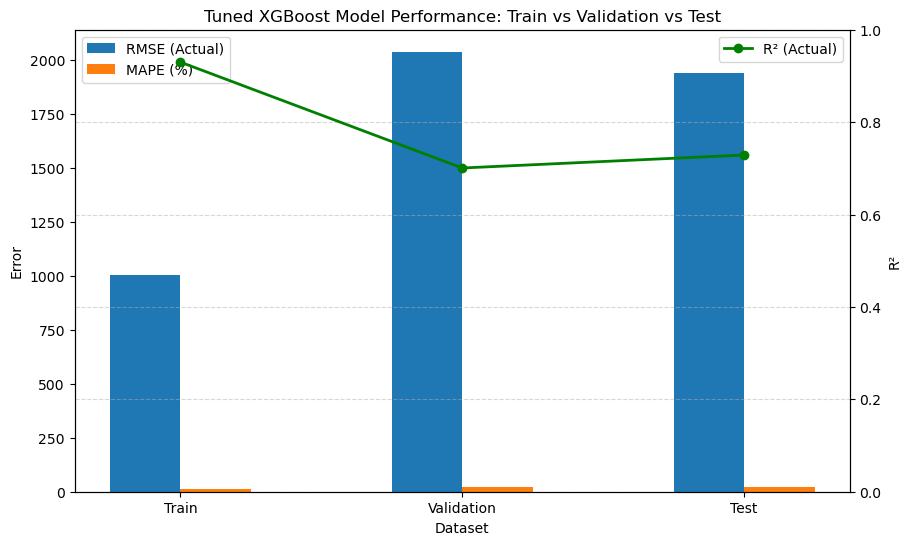

In [70]:
# Metrics to plot
datasets = ['Train', 'Validation', 'Test']
rmse_actual = [train_rmse_actual, val_rmse_actual, test_rmse_actual]
r2_actual = [train_r2_actual, val_r2_actual, test_r2_actual]
mape = [train_mape, val_mape, test_mape]

x = np.arange(len(datasets))  # the label locations
width = 0.25  # width of the bars

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot RMSE and MAPE as bars
ax1.bar(x - width/2, rmse_actual, width, label='RMSE (Actual)', color='#1f77b4')
ax1.bar(x + width/2, mape, width, label='MAPE (%)', color='#ff7f0e')
ax1.set_xlabel('Dataset')
ax1.set_ylabel('Error')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_title('Tuned XGBoost Model Performance: Train vs Validation vs Test')
ax1.legend(loc='upper left')

# Plot R² on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(datasets, r2_actual, color='green', marker='o', linewidth=2, label='R² (Actual)')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show();

C:\Users\USER\AppData\Local\Temp\ipykernel_15192\2868594596.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_mape_test = tier_performance_test.groupby('tier').apply(


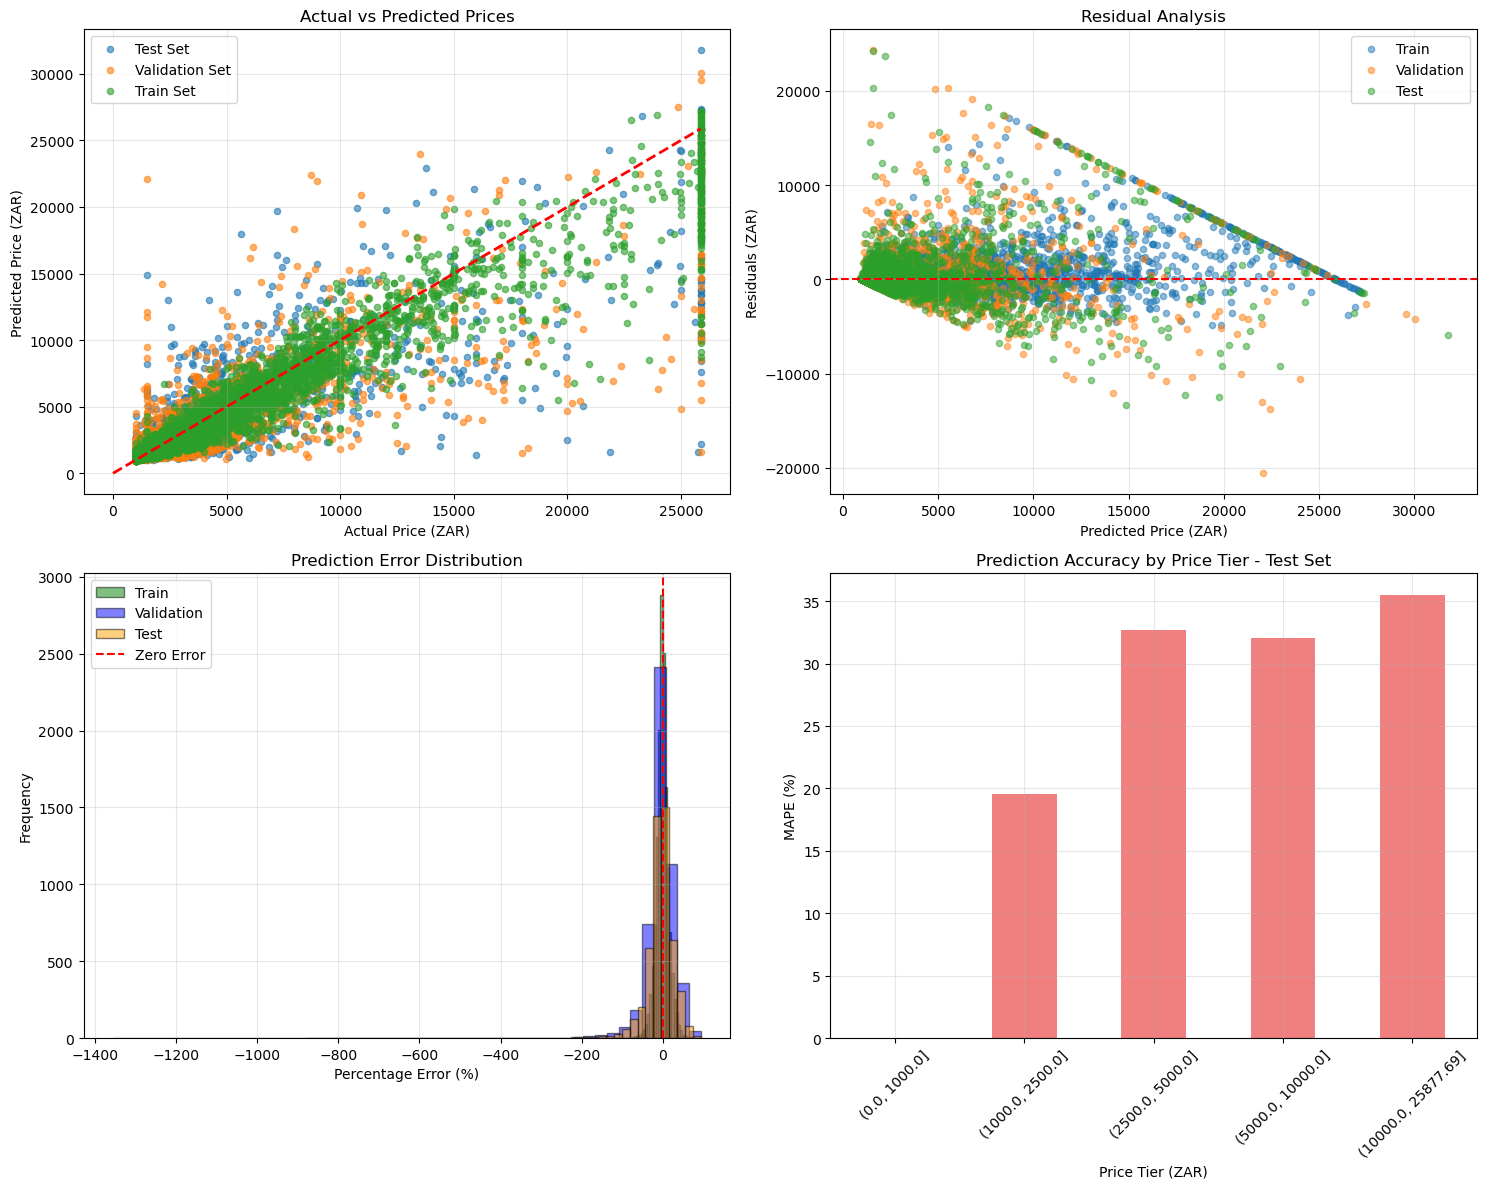

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted Prices - Test Set
axes[0,0].scatter(y_test_actual, y_test_pred, alpha=0.6, s=20, label='Test Set')
axes[0,0].scatter(y_val_actual, y_val_pred, alpha=0.6, s=20, label='Validation Set')
axes[0,0].scatter(y_train_actual, y_train_pred, alpha=0.6, s=20, label='Train Set')
axes[0,0].plot([0, max(y_test_actual.max(), y_train_actual.max())], 
               [0, max(y_test_actual.max(), y_train_actual.max())], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Price (ZAR)')
axes[0,0].set_ylabel('Predicted Price (ZAR)')
axes[0,0].set_title('Actual vs Predicted Prices')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Residual Analysis - Test Set
residuals_train = y_train_actual - y_train_pred
residuals_val = y_val_actual - y_val_pred
residuals_test = y_test_actual - y_test_pred

axes[0,1].scatter(y_train_pred, residuals_train, alpha=0.5, s=20, label='Train')
axes[0,1].scatter(y_val_pred, residuals_val, alpha=0.5, s=20, label='Validation')
axes[0,1].scatter(y_test_pred, residuals_test, alpha=0.5, s=20, label='Test')
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Price (ZAR)')
axes[0,1].set_ylabel('Residuals (ZAR)')
axes[0,1].set_title('Residual Analysis')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Error Distribution - Test Set
error_train = ((y_train_actual - y_train_pred) / y_train_actual) * 100
error_val = ((y_val_actual - y_val_pred) / y_val_actual) * 100
error_test = ((y_test_actual - y_test_pred) / y_test_actual) * 100

axes[1,0].hist(error_train, bins=50, alpha=0.5, label='Train', color='green', edgecolor='black')
axes[1,0].hist(error_val, bins=50, alpha=0.5, label='Validation', color='blue', edgecolor='black')
axes[1,0].hist(error_test, bins=50, alpha=0.5, label='Test', color='orange', edgecolor='black')
axes[1,0].axvline(x=0, color='r', linestyle='--', label='Zero Error')
axes[1,0].set_xlabel('Percentage Error (%)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Prediction Error Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Price Tier Performance - Test Set
price_tiers_test = pd.cut(y_test_actual, bins=[0, 1000, 2500, 5000, 10000, y_test_actual.max()])
tier_performance_test = pd.DataFrame({
    'actual': y_test_actual,
    'predicted': y_test_pred,
    'tier': price_tiers_test
})
tier_mape_test = tier_performance_test.groupby('tier').apply(
    lambda x: np.mean(np.abs((x['actual'] - x['predicted']) / x['actual'])) * 100
)
tier_mape_test.plot(kind='bar', ax=axes[1,1], color='lightcoral')
axes[1,1].set_xlabel('Price Tier (ZAR)')
axes[1,1].set_ylabel('MAPE (%)')
axes[1,1].set_title('Prediction Accuracy by Price Tier - Test Set')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 6. Conclusion
**Model Performance:**

The tuned XGBoost model achieved high accuracy on the training set (R2 = 0.93, RMSE = 1006), indicating it captures strong patterns in the data.

On validation and test sets, the performance decreased (R2 = 0.70-0.73, RMSE = 1941-2039), showing the model generalizes reasonably well but with some overfitting.

MAPE values (23%) suggest that on average, the model’s predicted prices deviate by around 23% from actual Airbnb listing prices. This level of error is acceptable for pricing guidance, though not perfect.

**Interpretability and Insights:**

The XGBoost model can provide feature importance scores, helping identify key factors affecting Airbnb prices in Cape Town, such as location, property type, and number of amenities.

This aligns with the project objective of not only predicting prices but also providing actionable insights for hosts.

**Business Objective Alignment:**

The model successfully provides data-driven pricing guidance, supporting hosts in setting competitive yet profitable Airbnb rates.

While predictions are not flawless, they are better than generic pricing strategies and can be fine-tuned further with updated data and additional features.

# 7. Recommendations
**Address Overfitting:**

- Consider further tuning XGBoost hyperparameters, such as increasing min_child_weight, reducing max_depth, or adding more regularization (lambda/alpha).

**Feature Engineering:**

- Include more features that capture dynamic pricing factors, e.g., local events, holidays, competitor prices, and seasonal trends.
- Encode categorical features more effectively (e.g., location clusters, property types) to improve predictive power.

**Continuous Model Improvement:**

- Retrain the model periodically as Airbnb listings and demand patterns change.
- Use feedback from host adoption to refine predictions, focusing on reducing the MAPE further below 20%.